# Importación

In [128]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data

In [129]:
salud19 = pd.read_csv('..\ENDES_2019-2023\CSALUD_2019.csv')
salud20 = pd.read_csv('..\ENDES_2019-2023\CSALUD_2020.csv')
salud21 = pd.read_csv('..\ENDES_2019-2023\CSALUD_2021.csv')
salud22 = pd.read_csv('..\ENDES_2019-2023\CSALUD_2022.csv')
salud23 = pd.read_csv('..\ENDES_2019-2023\CSALUD_2023.csv')

In [130]:
aux_map = {
    "LONGITUDX" : "longitudx",
    "LATITUDY" : "latitudy"
}

salud22 = salud22.rename(columns=aux_map)
salud23 = salud23.rename(columns=aux_map)

salud = pd.concat([salud19, salud20, salud21, salud22, salud23])
salud.columns = salud.columns.str.lower()
salud

,id1,hhid,qhcluster,qhnumber,qhhome,qsnumero,qsresult,qs20c,qssexo,qs23,...,hv023,hv024,hv025,hv026,ubigeo,nconglome,codccpp,nomccpp,longitudx,latitudy
0,2019,100201,1,2,1,2,1,2,2,33,...,1,1,1,1,10101,7065,1,CHACHAPOYAS,-77.87383,-6.223320
1,2019,102801,1,28,1,2,1,2,2,36,...,1,1,1,1,10101,7065,1,CHACHAPOYAS,-77.87383,-6.223320
2,2019,104801,1,48,1,2,1,2,2,28,...,1,1,1,1,10101,7065,1,CHACHAPOYAS,-77.87383,-6.223320
3,2019,113601,1,136,1,2,1,2,2,30,...,1,1,1,1,10101,7065,1,CHACHAPOYAS,-77.87383,-6.223320
4,2019,113701,1,137,1,2,2,,,,...,1,1,1,1,10101,7065,1,CHACHAPOYAS,-77.87383,-6.223320
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37481,2023,542903401,5429,34,1,2,2,,,,...,18,18,2,3,180202,4381201,1,CHOJATA,-70.73015,-16.388538
37482,2023,542904501,5429,45,1,2,1,2,2,56,...,18,18,2,3,180202,4381201,1,CHOJATA,-70.73015,-16.388538
37483,2023,542904701,5429,47,1,1,1,1,1,67,...,18,18,2,3,180202,4381201,1,CHOJATA,-70.73015,-16.388538
37484,2023,542904901,5429,49,1,4,5,4,2,55,...,18,18,2,3,180202,4381201,1,CHOJATA,-70.73015,-16.388538


In [131]:
columnas_eliminar = [
    "qhcluster",
    "qhnumber",
    "qhhome",
    "qsnumero",
    "qs24",
    "qs25n",
    "qs26",
    "qs27",
    "qs201",
    "qs202",
    "qs210",
    "qs215u",
    "qs215c",
    "qs902",
    "qs906",
    "qs907",
    "qs908",
    "hv023",
    "qs702", "qs703", "qs704a", "qs704b", "qs704c", "qs704d", "qs704e", "qs704f", "qs704g",
    "qs704h", "qs704i", "qs706", "qs709"
]

salud = salud.drop(columns=columnas_eliminar)
salud

,id1,hhid,qsresult,qs20c,qssexo,qs23,qs102,qs700a,qs700b,qs700c,...,qs905d,hv024,hv025,hv026,ubigeo,nconglome,codccpp,nomccpp,longitudx,latitudy
0,2019,100201,1,2,2,33,2,0,0,0,...,59,1,1,1,10101,7065,1,CHACHAPOYAS,-77.87383,-6.223320
1,2019,102801,1,2,2,36,2,1,0,0,...,75,1,1,1,10101,7065,1,CHACHAPOYAS,-77.87383,-6.223320
2,2019,104801,1,2,2,28,2,0,0,0,...,77,1,1,1,10101,7065,1,CHACHAPOYAS,-77.87383,-6.223320
3,2019,113601,1,2,2,30,2,1,1,0,...,61,1,1,1,10101,7065,1,CHACHAPOYAS,-77.87383,-6.223320
4,2019,113701,2,,,,,,,,...,,1,1,1,10101,7065,1,CHACHAPOYAS,-77.87383,-6.223320
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37481,2023,542903401,2,,,,,,,,...,,18,2,3,180202,4381201,1,CHOJATA,-70.73015,-16.388538
37482,2023,542904501,1,2,2,56,2,0,0,0,...,76,18,2,3,180202,4381201,1,CHOJATA,-70.73015,-16.388538
37483,2023,542904701,1,1,1,67,1,3,3,0,...,81,18,2,3,180202,4381201,1,CHOJATA,-70.73015,-16.388538
37484,2023,542904901,5,4,2,55,2,0,0,1,...,59,18,2,3,180202,4381201,1,CHOJATA,-70.73015,-16.388538


In [132]:
columnas_diccionario = {
    "id1": "anio",
    "hhid": "id_hogar",
    "qsresult": "cod_resultado",
    "qs20c": "cod_persona",
    "qssexo": "sexo",
    "qs23": "edad",
    "qs102": "diagnostico_hipertension",
    "qs900": "peso_kg",
    "qs901": "talla_cm",
    "qs903s": "presion_sis_1",
    "qs903d": "presion_dia_1",
    "qs905s": "presion_sis_2",
    "qs905d": "presion_dia_2",
    "hv024": "region",
    "hv025": "area_residencia",
    "hv026": "lugar_residencia",
    "ubigeo": "codigo_ubicacion_geo",
    "nconglome": "num_conglomerado",
    "codccpp": "codigo_centro_poblado",
    "nomccpp": "nombre_centro_poblado",
    "latitudy": "latitud",
    "longitudx": "longitud",
    
    #qs700a al qs700i
    "qs700a": "poco_interes_14d",
    "qs700b": "deprimido_14d",
    "qs700c": "problema_dormir_14d",
    "qs700d": "cansancio_14d",
    "qs700e": "problema_comer_14d",
    "qs700f": "problema_atencion_14d",
    "qs700g": "problema_moverse_14d",
    "qs700h": "pensamiento_suicida_14d", #duda en el nombre
    "qs700i": "sentirse_mal_14d"
}

salud = salud.rename(columns=columnas_diccionario)
salud

,anio,id_hogar,cod_resultado,cod_persona,sexo,edad,diagnostico_hipertension,poco_interes_14d,deprimido_14d,problema_dormir_14d,...,presion_dia_2,region,area_residencia,lugar_residencia,codigo_ubicacion_geo,num_conglomerado,codigo_centro_poblado,nombre_centro_poblado,longitud,latitud
0,2019,100201,1,2,2,33,2,0,0,0,...,59,1,1,1,10101,7065,1,CHACHAPOYAS,-77.87383,-6.223320
1,2019,102801,1,2,2,36,2,1,0,0,...,75,1,1,1,10101,7065,1,CHACHAPOYAS,-77.87383,-6.223320
2,2019,104801,1,2,2,28,2,0,0,0,...,77,1,1,1,10101,7065,1,CHACHAPOYAS,-77.87383,-6.223320
3,2019,113601,1,2,2,30,2,1,1,0,...,61,1,1,1,10101,7065,1,CHACHAPOYAS,-77.87383,-6.223320
4,2019,113701,2,,,,,,,,...,,1,1,1,10101,7065,1,CHACHAPOYAS,-77.87383,-6.223320
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37481,2023,542903401,2,,,,,,,,...,,18,2,3,180202,4381201,1,CHOJATA,-70.73015,-16.388538
37482,2023,542904501,1,2,2,56,2,0,0,0,...,76,18,2,3,180202,4381201,1,CHOJATA,-70.73015,-16.388538
37483,2023,542904701,1,1,1,67,1,3,3,0,...,81,18,2,3,180202,4381201,1,CHOJATA,-70.73015,-16.388538
37484,2023,542904901,5,4,2,55,2,0,0,1,...,59,18,2,3,180202,4381201,1,CHOJATA,-70.73015,-16.388538


In [133]:
estado_encuesta = {
    "1": "completa",
    "2": "ausente",
    "3": "aplazada",
    "4": "rechazada",
    "5": "incompleta",
    "6": "discapacitado",
    "9": "otra"
}

salud["cod_resultado"] = salud["cod_resultado"].map(estado_encuesta)

sexo = {
    "1": "hombre",
    "2": "mujer"
}

salud["sexo"] = salud["sexo"].map(sexo)

respuesta_dict = {
    "1": "si",
    "2": "no",
    "8": "no_sabe_no_recuerda"
}
salud["diagnostico_hipertension"] = salud["diagnostico_hipertension"].map(respuesta_dict)

regiones_dict = {
    1: "amazonas",
    2: "ancash",
    3: "apurimac",
    4: "arequipa",
    5: "ayacucho",
    6: "cajamarca",
    7: "callao",
    8: "cusco",
    9: "huancavelica",
    10: "huanuco",
    11: "ica",
    12: "junin",
    13: "la_libertad",
    14: "lambayeque",
    15: "lima",
    16: "loreto",
    17: "madre_de_dios",
    18: "moquegua",
    19: "pasco",
    20: "piura",
    21: "puno",
    22: "san_martin",
    23: "tacna",
    24: "tumbes",
    25: "ucayali"
}

salud["region"] = salud["region"].map(regiones_dict)

area_residencia_dict = {
    1: "urbano",
    2: "rural"
}
salud["area_residencia"] = salud["area_residencia"].map(area_residencia_dict)

lugar_residencia_dict = {
    0: "capital_gran_ciudad",
    1: "pequena_ciudad",
    2: "pueblo",
    3: "campo"
}
salud["lugar_residencia"] = salud["lugar_residencia"].map(lugar_residencia_dict)

# phq9_dict = {
#     "0": "para_nada",
#     "1": "varios_dias",
#     "2": "mayoria_dias",
#     "3": "casi_todos_dias"
# }

# salud["poco_interes_14d"] = salud["poco_interes_14d"].map(phq9_dict)
# salud["deprimido_14d"] = salud["deprimido_14d"].map(phq9_dict)
# salud["problema_dormir_14d"] = salud["problema_dormir_14d"].map(phq9_dict)
# salud["cansancio_14d"] = salud["cansancio_14d"].map(phq9_dict)
# salud["problema_comer_14d"] = salud["problema_comer_14d"].map(phq9_dict)
# salud["problema_atencion_14d"] = salud["problema_atencion_14d"].map(phq9_dict)
# salud["problema_moverse_14d"] = salud["problema_moverse_14d"].map(phq9_dict)
# salud["pensamiento_suicida_14d"] = salud["pensamiento_suicida_14d"].map(phq9_dict)
# salud["sentirse_mal_14d"] = salud["sentirse_mal_14d"].map(phq9_dict)

salud

,anio,id_hogar,cod_resultado,cod_persona,sexo,edad,diagnostico_hipertension,poco_interes_14d,deprimido_14d,problema_dormir_14d,...,presion_dia_2,region,area_residencia,lugar_residencia,codigo_ubicacion_geo,num_conglomerado,codigo_centro_poblado,nombre_centro_poblado,longitud,latitud
0,2019,100201,completa,2,mujer,33,no,0,0,0,...,59,amazonas,urbano,pequena_ciudad,10101,7065,1,CHACHAPOYAS,-77.87383,-6.223320
1,2019,102801,completa,2,mujer,36,no,1,0,0,...,75,amazonas,urbano,pequena_ciudad,10101,7065,1,CHACHAPOYAS,-77.87383,-6.223320
2,2019,104801,completa,2,mujer,28,no,0,0,0,...,77,amazonas,urbano,pequena_ciudad,10101,7065,1,CHACHAPOYAS,-77.87383,-6.223320
3,2019,113601,completa,2,mujer,30,no,1,1,0,...,61,amazonas,urbano,pequena_ciudad,10101,7065,1,CHACHAPOYAS,-77.87383,-6.223320
4,2019,113701,ausente,,NaN,,NaN,,,,...,,amazonas,urbano,pequena_ciudad,10101,7065,1,CHACHAPOYAS,-77.87383,-6.223320
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37481,2023,542903401,ausente,,NaN,,NaN,,,,...,,moquegua,rural,campo,180202,4381201,1,CHOJATA,-70.73015,-16.388538
37482,2023,542904501,completa,2,mujer,56,no,0,0,0,...,76,moquegua,rural,campo,180202,4381201,1,CHOJATA,-70.73015,-16.388538
37483,2023,542904701,completa,1,hombre,67,si,3,3,0,...,81,moquegua,rural,campo,180202,4381201,1,CHOJATA,-70.73015,-16.388538
37484,2023,542904901,incompleta,4,mujer,55,no,0,0,1,...,59,moquegua,rural,campo,180202,4381201,1,CHOJATA,-70.73015,-16.388538


In [134]:
salud["edad"] = pd.to_numeric(salud["edad"], errors="coerce")
salud["peso_kg"] = pd.to_numeric(salud["peso_kg"], errors="coerce")
salud["talla_cm"] = pd.to_numeric(salud["talla_cm"], errors="coerce")
salud["presion_sis_1"] = pd.to_numeric(salud["presion_sis_1"], errors="coerce")
salud["presion_dia_1"] = pd.to_numeric(salud["presion_dia_1"], errors="coerce")
salud["presion_sis_2"] = pd.to_numeric(salud["presion_sis_2"], errors="coerce")
salud["presion_dia_2"] = pd.to_numeric(salud["presion_dia_2"], errors="coerce")

salud["poco_interes_14d"] = pd.to_numeric(salud["poco_interes_14d"], errors="coerce")
salud["deprimido_14d"] = pd.to_numeric(salud["deprimido_14d"], errors="coerce")
salud["problema_dormir_14d"] = pd.to_numeric(salud["problema_dormir_14d"], errors="coerce")
salud["cansancio_14d"] = pd.to_numeric(salud["cansancio_14d"], errors="coerce")
salud["problema_comer_14d"] = pd.to_numeric(salud["problema_comer_14d"], errors="coerce")
salud["problema_atencion_14d"] = pd.to_numeric(salud["problema_atencion_14d"], errors="coerce")
salud["problema_moverse_14d"] = pd.to_numeric(salud["problema_moverse_14d"], errors="coerce")
salud["pensamiento_suicida_14d"] = pd.to_numeric(salud["pensamiento_suicida_14d"], errors="coerce")
salud["sentirse_mal_14d"] = pd.to_numeric(salud["sentirse_mal_14d"], errors="coerce")

salud["nombre_centro_poblado"] = salud["nombre_centro_poblado"].str.lower()
salud

,anio,id_hogar,cod_resultado,cod_persona,sexo,edad,diagnostico_hipertension,poco_interes_14d,deprimido_14d,problema_dormir_14d,...,presion_dia_2,region,area_residencia,lugar_residencia,codigo_ubicacion_geo,num_conglomerado,codigo_centro_poblado,nombre_centro_poblado,longitud,latitud
0,2019,100201,completa,2,mujer,33.0,no,0.0,0.0,0.0,...,59.0,amazonas,urbano,pequena_ciudad,10101,7065,1,chachapoyas,-77.87383,-6.223320
1,2019,102801,completa,2,mujer,36.0,no,1.0,0.0,0.0,...,75.0,amazonas,urbano,pequena_ciudad,10101,7065,1,chachapoyas,-77.87383,-6.223320
2,2019,104801,completa,2,mujer,28.0,no,0.0,0.0,0.0,...,77.0,amazonas,urbano,pequena_ciudad,10101,7065,1,chachapoyas,-77.87383,-6.223320
3,2019,113601,completa,2,mujer,30.0,no,1.0,1.0,0.0,...,61.0,amazonas,urbano,pequena_ciudad,10101,7065,1,chachapoyas,-77.87383,-6.223320
4,2019,113701,ausente,,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,amazonas,urbano,pequena_ciudad,10101,7065,1,chachapoyas,-77.87383,-6.223320
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37481,2023,542903401,ausente,,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,moquegua,rural,campo,180202,4381201,1,chojata,-70.73015,-16.388538
37482,2023,542904501,completa,2,mujer,56.0,no,0.0,0.0,0.0,...,76.0,moquegua,rural,campo,180202,4381201,1,chojata,-70.73015,-16.388538
37483,2023,542904701,completa,1,hombre,67.0,si,3.0,3.0,0.0,...,81.0,moquegua,rural,campo,180202,4381201,1,chojata,-70.73015,-16.388538
37484,2023,542904901,incompleta,4,mujer,55.0,no,0.0,0.0,1.0,...,59.0,moquegua,rural,campo,180202,4381201,1,chojata,-70.73015,-16.388538


# Limpieza

In [135]:
#convertir los valores " " a NaN
salud = salud.replace(" ", np.nan)
salud

,anio,id_hogar,cod_resultado,cod_persona,sexo,edad,diagnostico_hipertension,poco_interes_14d,deprimido_14d,problema_dormir_14d,...,presion_dia_2,region,area_residencia,lugar_residencia,codigo_ubicacion_geo,num_conglomerado,codigo_centro_poblado,nombre_centro_poblado,longitud,latitud
0,2019,100201,completa,2,mujer,33.0,no,0.0,0.0,0.0,...,59.0,amazonas,urbano,pequena_ciudad,10101,7065,1,chachapoyas,-77.87383,-6.223320
1,2019,102801,completa,2,mujer,36.0,no,1.0,0.0,0.0,...,75.0,amazonas,urbano,pequena_ciudad,10101,7065,1,chachapoyas,-77.87383,-6.223320
2,2019,104801,completa,2,mujer,28.0,no,0.0,0.0,0.0,...,77.0,amazonas,urbano,pequena_ciudad,10101,7065,1,chachapoyas,-77.87383,-6.223320
3,2019,113601,completa,2,mujer,30.0,no,1.0,1.0,0.0,...,61.0,amazonas,urbano,pequena_ciudad,10101,7065,1,chachapoyas,-77.87383,-6.223320
4,2019,113701,ausente,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,amazonas,urbano,pequena_ciudad,10101,7065,1,chachapoyas,-77.87383,-6.223320
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37481,2023,542903401,ausente,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,moquegua,rural,campo,180202,4381201,1,chojata,-70.73015,-16.388538
37482,2023,542904501,completa,2,mujer,56.0,no,0.0,0.0,0.0,...,76.0,moquegua,rural,campo,180202,4381201,1,chojata,-70.73015,-16.388538
37483,2023,542904701,completa,1,hombre,67.0,si,3.0,3.0,0.0,...,81.0,moquegua,rural,campo,180202,4381201,1,chojata,-70.73015,-16.388538
37484,2023,542904901,incompleta,4,mujer,55.0,no,0.0,0.0,1.0,...,59.0,moquegua,rural,campo,180202,4381201,1,chojata,-70.73015,-16.388538


In [136]:
#filtrar solo cod_resultado = completa
salud = salud[salud["cod_resultado"] == "completa"]
salud

,anio,id_hogar,cod_resultado,cod_persona,sexo,edad,diagnostico_hipertension,poco_interes_14d,deprimido_14d,problema_dormir_14d,...,presion_dia_2,region,area_residencia,lugar_residencia,codigo_ubicacion_geo,num_conglomerado,codigo_centro_poblado,nombre_centro_poblado,longitud,latitud
0,2019,100201,completa,2,mujer,33.0,no,0.0,0.0,0.0,...,59.0,amazonas,urbano,pequena_ciudad,10101,7065,1,chachapoyas,-77.87383,-6.223320
1,2019,102801,completa,2,mujer,36.0,no,1.0,0.0,0.0,...,75.0,amazonas,urbano,pequena_ciudad,10101,7065,1,chachapoyas,-77.87383,-6.223320
2,2019,104801,completa,2,mujer,28.0,no,0.0,0.0,0.0,...,77.0,amazonas,urbano,pequena_ciudad,10101,7065,1,chachapoyas,-77.87383,-6.223320
3,2019,113601,completa,2,mujer,30.0,no,1.0,1.0,0.0,...,61.0,amazonas,urbano,pequena_ciudad,10101,7065,1,chachapoyas,-77.87383,-6.223320
5,2019,116701,completa,1,mujer,18.0,no,0.0,0.0,0.0,...,70.0,amazonas,urbano,pequena_ciudad,10101,7065,1,chachapoyas,-77.87383,-6.223320
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37478,2023,542901901,completa,2,mujer,71.0,no,0.0,1.0,3.0,...,77.0,moquegua,rural,campo,180202,4381201,1,chojata,-70.73015,-16.388538
37480,2023,542903101,completa,1,hombre,64.0,no,0.0,0.0,0.0,...,81.0,moquegua,rural,campo,180202,4381201,1,chojata,-70.73015,-16.388538
37482,2023,542904501,completa,2,mujer,56.0,no,0.0,0.0,0.0,...,76.0,moquegua,rural,campo,180202,4381201,1,chojata,-70.73015,-16.388538
37483,2023,542904701,completa,1,hombre,67.0,si,3.0,3.0,0.0,...,81.0,moquegua,rural,campo,180202,4381201,1,chojata,-70.73015,-16.388538


In [137]:
#reemplazar los 999.9 por NaN
salud = salud.replace(999.9, np.nan)
salud = salud.replace (999.0, np.nan)
salud

,anio,id_hogar,cod_resultado,cod_persona,sexo,edad,diagnostico_hipertension,poco_interes_14d,deprimido_14d,problema_dormir_14d,...,presion_dia_2,region,area_residencia,lugar_residencia,codigo_ubicacion_geo,num_conglomerado,codigo_centro_poblado,nombre_centro_poblado,longitud,latitud
0,2019,100201,completa,2,mujer,33.0,no,0.0,0.0,0.0,...,59.0,amazonas,urbano,pequena_ciudad,10101,7065,1,chachapoyas,-77.87383,-6.223320
1,2019,102801,completa,2,mujer,36.0,no,1.0,0.0,0.0,...,75.0,amazonas,urbano,pequena_ciudad,10101,7065,1,chachapoyas,-77.87383,-6.223320
2,2019,104801,completa,2,mujer,28.0,no,0.0,0.0,0.0,...,77.0,amazonas,urbano,pequena_ciudad,10101,7065,1,chachapoyas,-77.87383,-6.223320
3,2019,113601,completa,2,mujer,30.0,no,1.0,1.0,0.0,...,61.0,amazonas,urbano,pequena_ciudad,10101,7065,1,chachapoyas,-77.87383,-6.223320
5,2019,116701,completa,1,mujer,18.0,no,0.0,0.0,0.0,...,70.0,amazonas,urbano,pequena_ciudad,10101,7065,1,chachapoyas,-77.87383,-6.223320
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37478,2023,542901901,completa,2,mujer,71.0,no,0.0,1.0,3.0,...,77.0,moquegua,rural,campo,180202,4381201,1,chojata,-70.73015,-16.388538
37480,2023,542903101,completa,1,hombre,64.0,no,0.0,0.0,0.0,...,81.0,moquegua,rural,campo,180202,4381201,1,chojata,-70.73015,-16.388538
37482,2023,542904501,completa,2,mujer,56.0,no,0.0,0.0,0.0,...,76.0,moquegua,rural,campo,180202,4381201,1,chojata,-70.73015,-16.388538
37483,2023,542904701,completa,1,hombre,67.0,si,3.0,3.0,0.0,...,81.0,moquegua,rural,campo,180202,4381201,1,chojata,-70.73015,-16.388538


In [138]:
# eliminar las filas que tengan 6 a más valores nan
salud = salud.dropna(thresh=salud.shape[1] - 5)
salud

,anio,id_hogar,cod_resultado,cod_persona,sexo,edad,diagnostico_hipertension,poco_interes_14d,deprimido_14d,problema_dormir_14d,...,presion_dia_2,region,area_residencia,lugar_residencia,codigo_ubicacion_geo,num_conglomerado,codigo_centro_poblado,nombre_centro_poblado,longitud,latitud
0,2019,100201,completa,2,mujer,33.0,no,0.0,0.0,0.0,...,59.0,amazonas,urbano,pequena_ciudad,10101,7065,1,chachapoyas,-77.87383,-6.223320
1,2019,102801,completa,2,mujer,36.0,no,1.0,0.0,0.0,...,75.0,amazonas,urbano,pequena_ciudad,10101,7065,1,chachapoyas,-77.87383,-6.223320
2,2019,104801,completa,2,mujer,28.0,no,0.0,0.0,0.0,...,77.0,amazonas,urbano,pequena_ciudad,10101,7065,1,chachapoyas,-77.87383,-6.223320
3,2019,113601,completa,2,mujer,30.0,no,1.0,1.0,0.0,...,61.0,amazonas,urbano,pequena_ciudad,10101,7065,1,chachapoyas,-77.87383,-6.223320
5,2019,116701,completa,1,mujer,18.0,no,0.0,0.0,0.0,...,70.0,amazonas,urbano,pequena_ciudad,10101,7065,1,chachapoyas,-77.87383,-6.223320
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37478,2023,542901901,completa,2,mujer,71.0,no,0.0,1.0,3.0,...,77.0,moquegua,rural,campo,180202,4381201,1,chojata,-70.73015,-16.388538
37480,2023,542903101,completa,1,hombre,64.0,no,0.0,0.0,0.0,...,81.0,moquegua,rural,campo,180202,4381201,1,chojata,-70.73015,-16.388538
37482,2023,542904501,completa,2,mujer,56.0,no,0.0,0.0,0.0,...,76.0,moquegua,rural,campo,180202,4381201,1,chojata,-70.73015,-16.388538
37483,2023,542904701,completa,1,hombre,67.0,si,3.0,3.0,0.0,...,81.0,moquegua,rural,campo,180202,4381201,1,chojata,-70.73015,-16.388538


In [139]:
salud.isna().sum()

anio                          0
id_hogar                      0
cod_resultado                 0
cod_persona                   0
sexo                          0
edad                          0
diagnostico_hipertension      0
poco_interes_14d              0
deprimido_14d                 0
problema_dormir_14d           0
cansancio_14d                 0
problema_comer_14d            0
problema_atencion_14d         0
problema_moverse_14d          0
pensamiento_suicida_14d       0
sentirse_mal_14d              0
peso_kg                     385
talla_cm                    388
presion_sis_1                23
presion_dia_1                23
presion_sis_2                23
presion_dia_2                23
region                        0
area_residencia               0
lugar_residencia              0
codigo_ubicacion_geo          0
num_conglomerado              0
codigo_centro_poblado         0
nombre_centro_poblado         0
longitud                      0
latitud                       0
dtype: i

In [140]:
import missingno
import matplotlib

print("missingno:", missingno.__version__)
print("matplotlib:", matplotlib.__version__)


missingno: 0.5.2
matplotlib: 3.10.6


<Axes: >

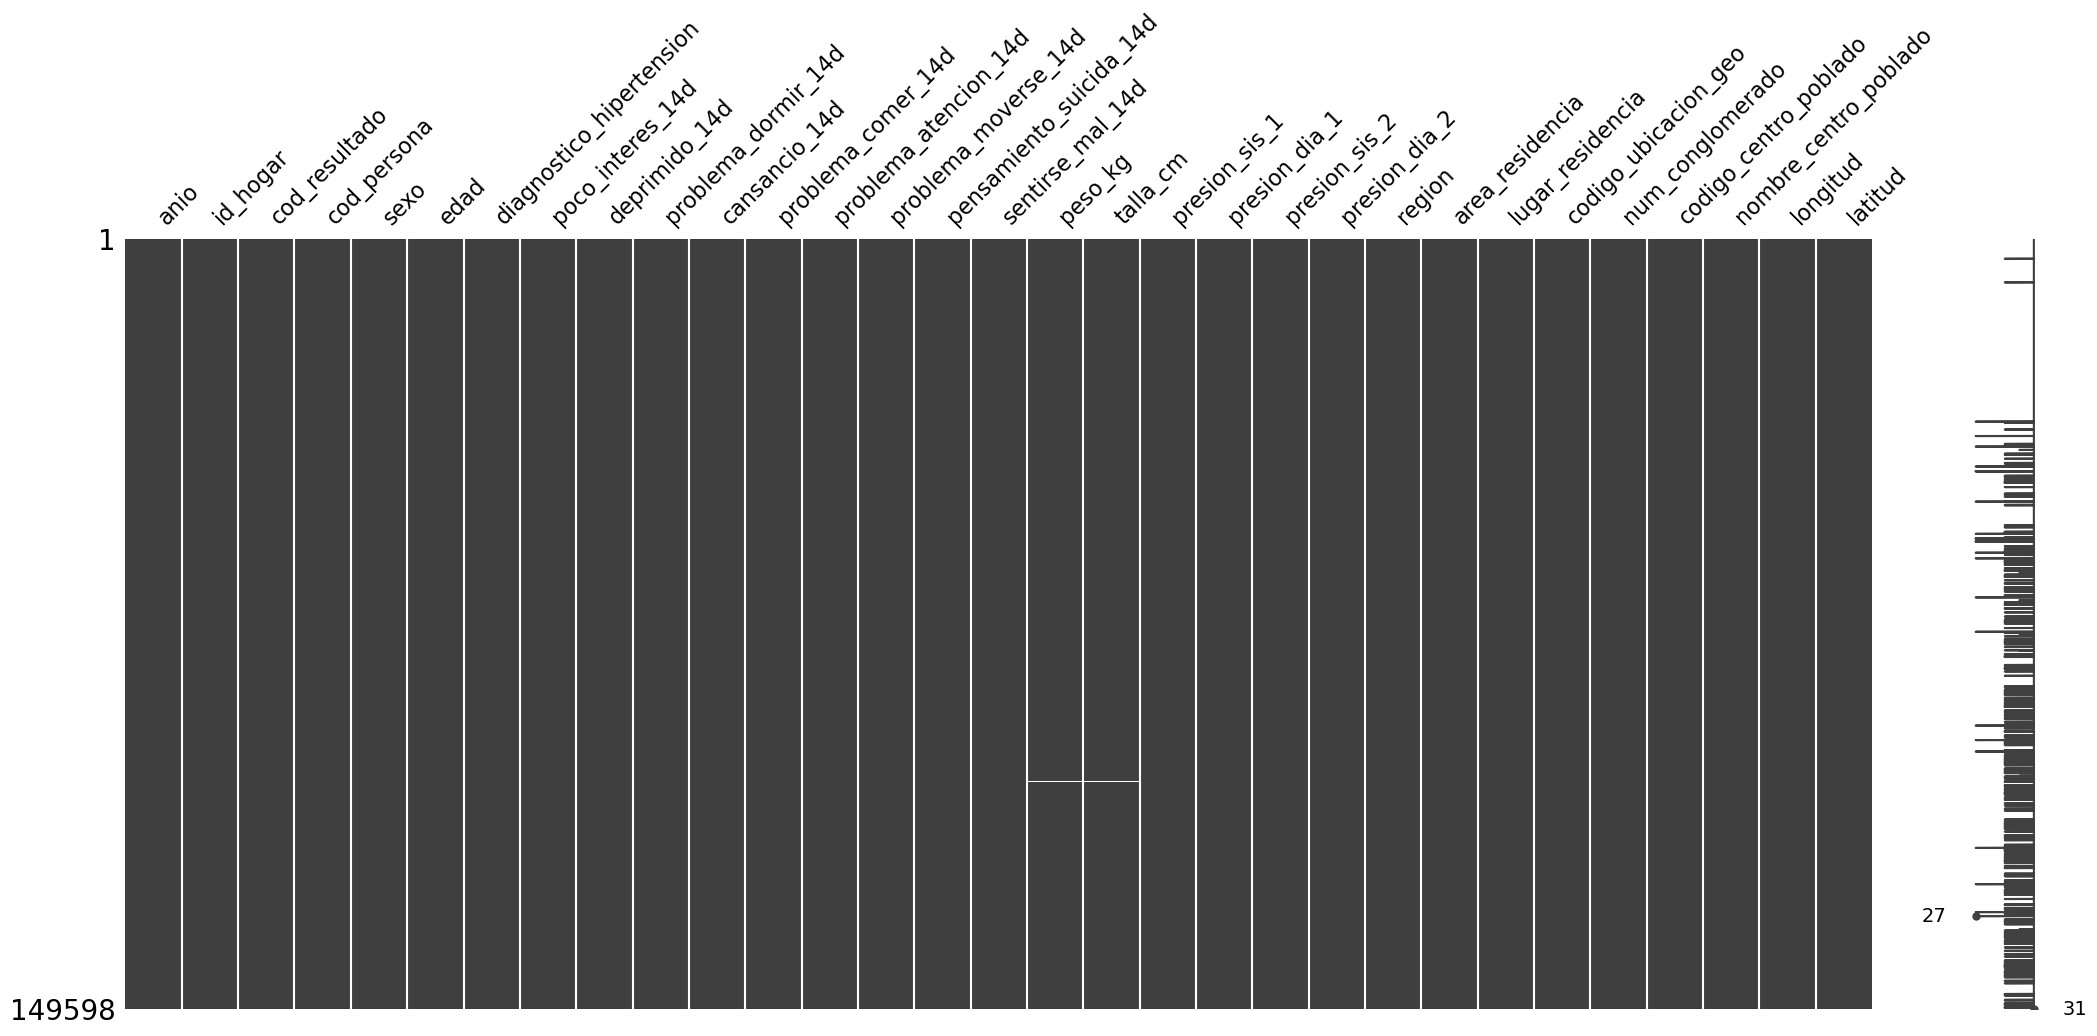

In [141]:
import missingno as msno

msno.matrix(salud)

<Axes: >

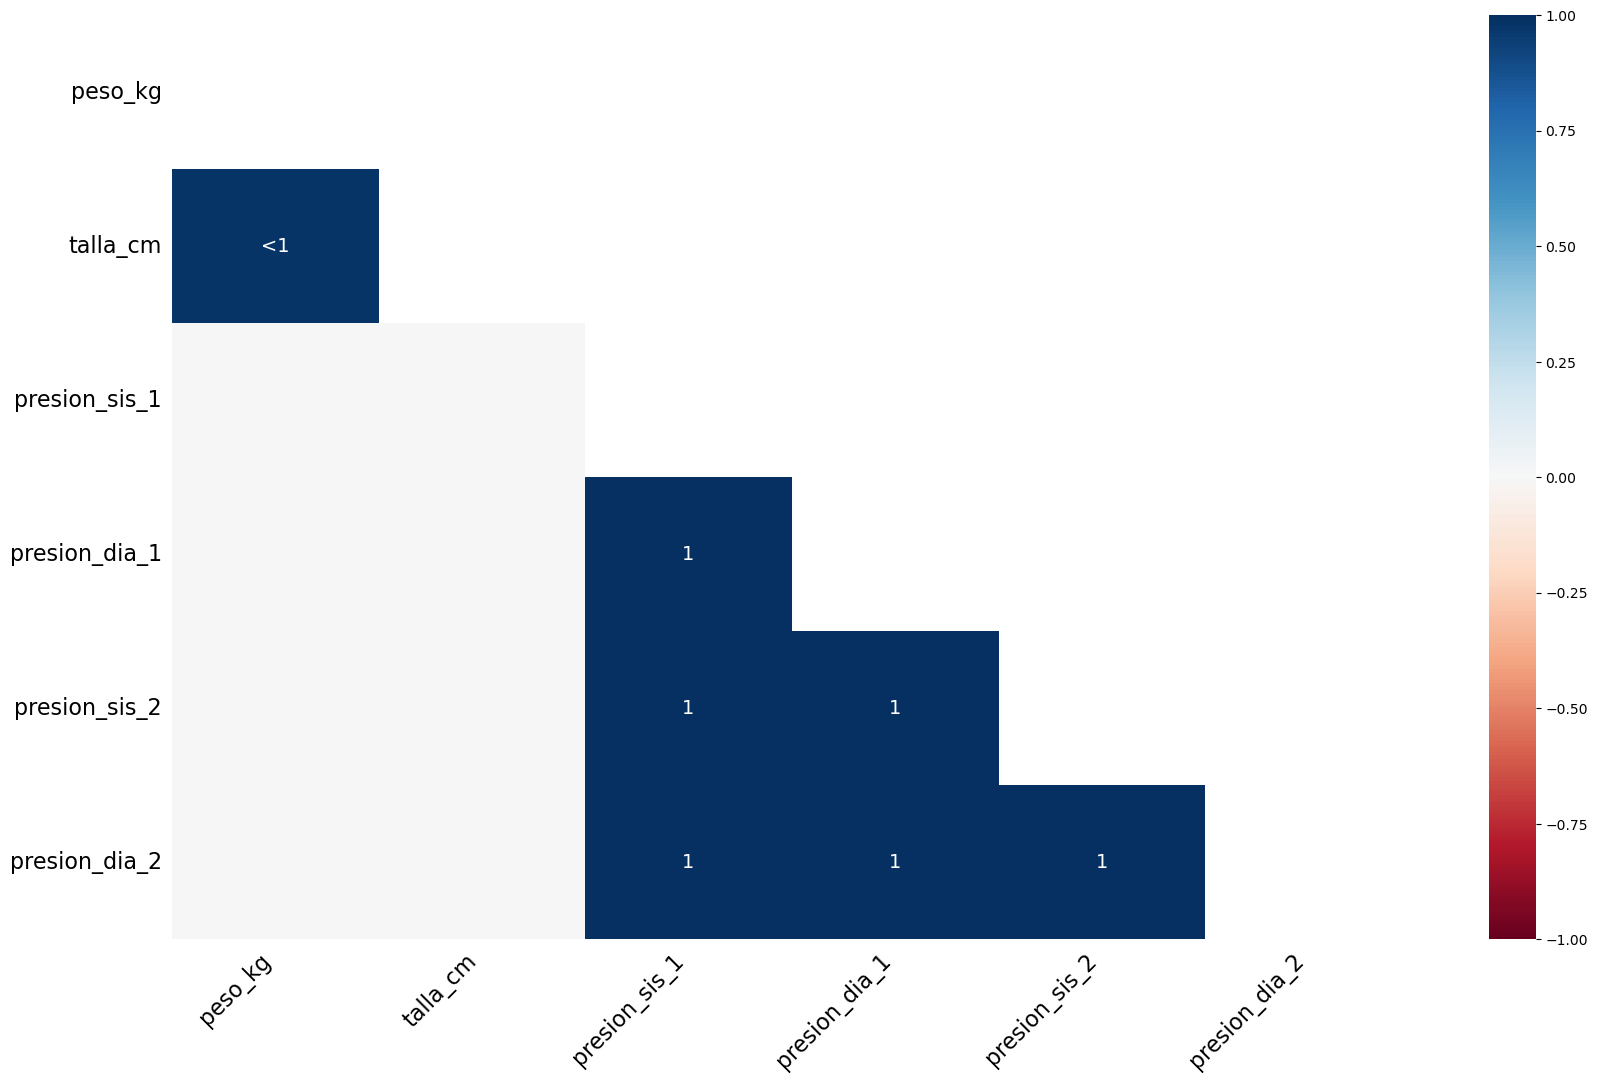

In [142]:
msno.heatmap(salud)

<Axes: >

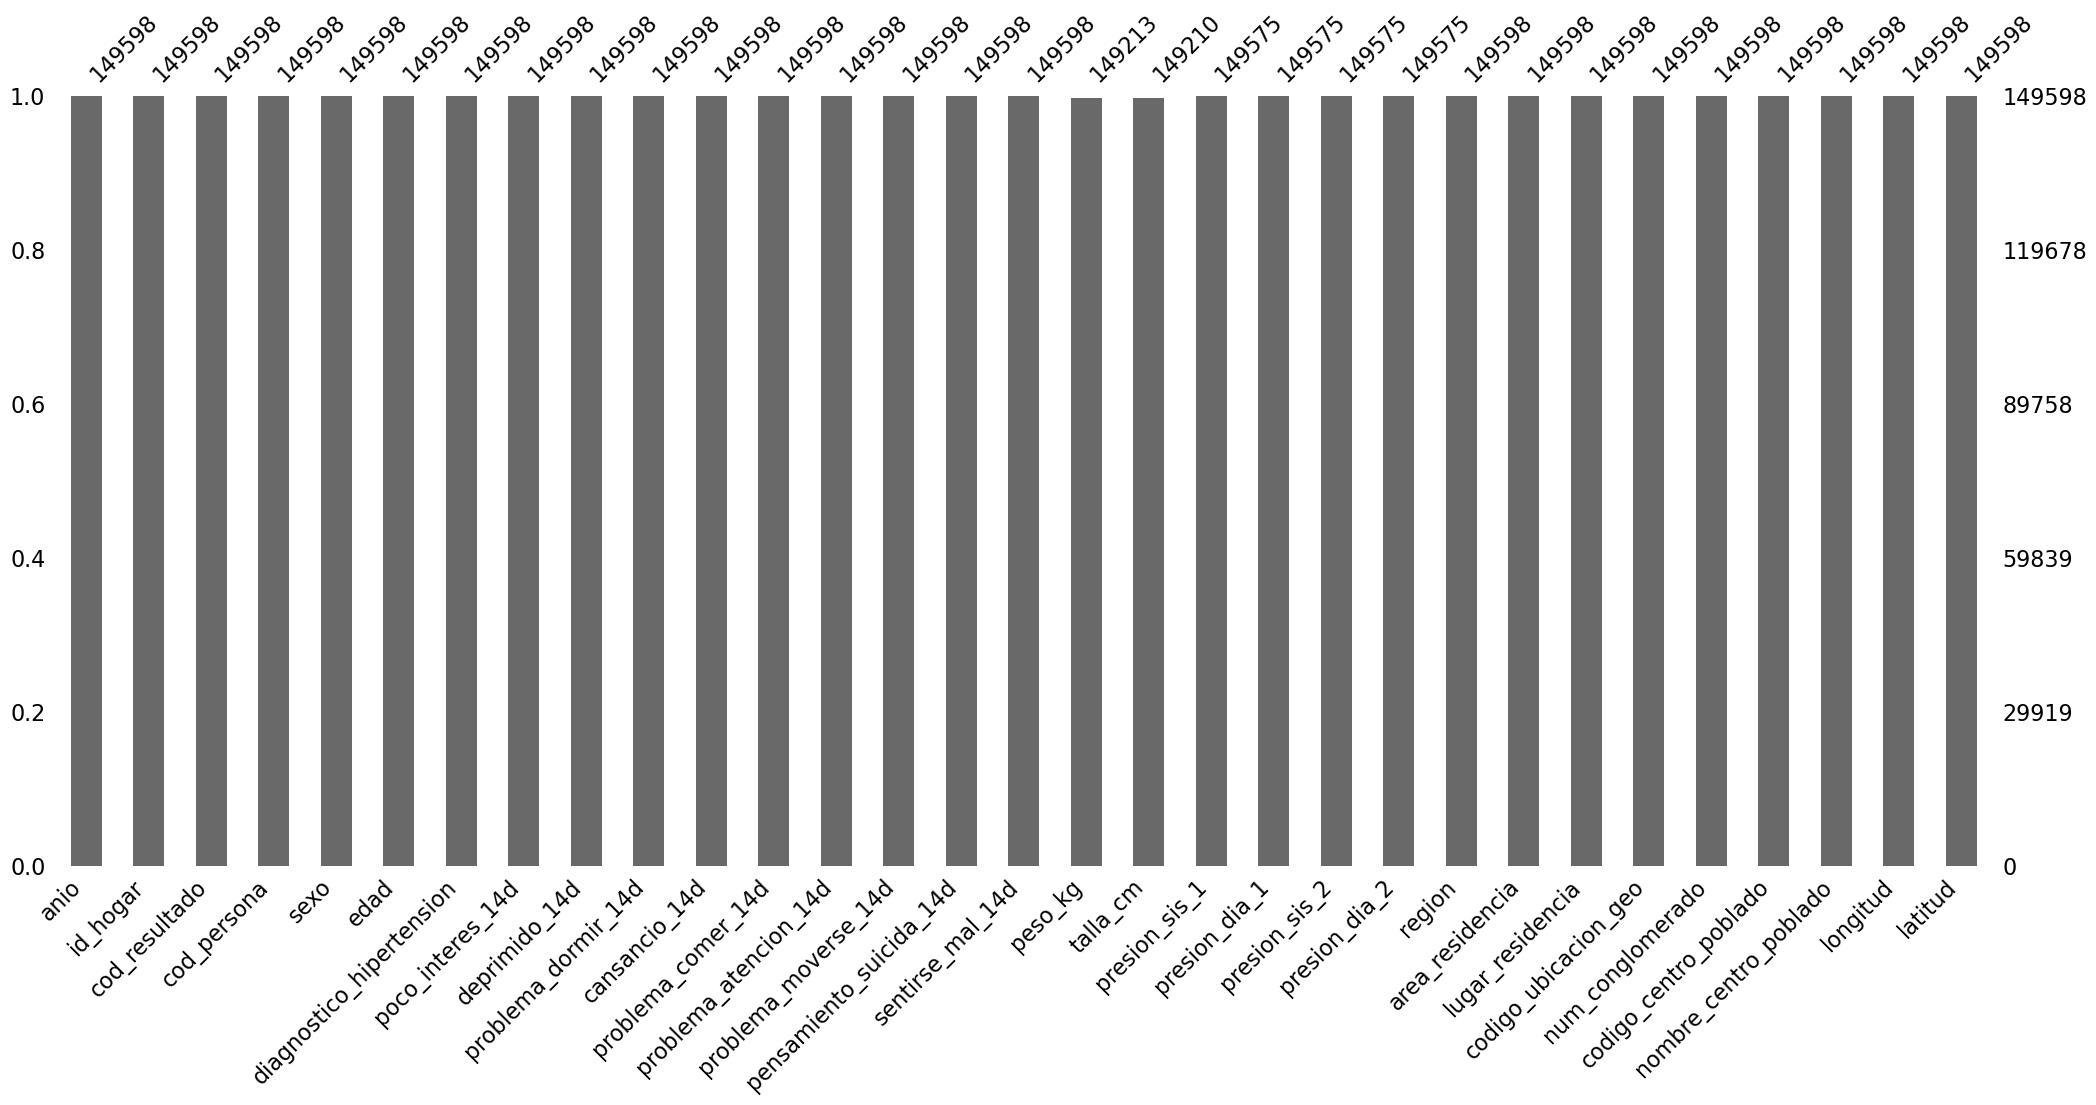

In [143]:
msno.bar(salud)

# Exclusiones

## Menores de 18 años

In [144]:
salud = salud[salud["edad"] >= 18]
salud

,anio,id_hogar,cod_resultado,cod_persona,sexo,edad,diagnostico_hipertension,poco_interes_14d,deprimido_14d,problema_dormir_14d,...,presion_dia_2,region,area_residencia,lugar_residencia,codigo_ubicacion_geo,num_conglomerado,codigo_centro_poblado,nombre_centro_poblado,longitud,latitud
0,2019,100201,completa,2,mujer,33.0,no,0.0,0.0,0.0,...,59.0,amazonas,urbano,pequena_ciudad,10101,7065,1,chachapoyas,-77.87383,-6.223320
1,2019,102801,completa,2,mujer,36.0,no,1.0,0.0,0.0,...,75.0,amazonas,urbano,pequena_ciudad,10101,7065,1,chachapoyas,-77.87383,-6.223320
2,2019,104801,completa,2,mujer,28.0,no,0.0,0.0,0.0,...,77.0,amazonas,urbano,pequena_ciudad,10101,7065,1,chachapoyas,-77.87383,-6.223320
3,2019,113601,completa,2,mujer,30.0,no,1.0,1.0,0.0,...,61.0,amazonas,urbano,pequena_ciudad,10101,7065,1,chachapoyas,-77.87383,-6.223320
5,2019,116701,completa,1,mujer,18.0,no,0.0,0.0,0.0,...,70.0,amazonas,urbano,pequena_ciudad,10101,7065,1,chachapoyas,-77.87383,-6.223320
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37478,2023,542901901,completa,2,mujer,71.0,no,0.0,1.0,3.0,...,77.0,moquegua,rural,campo,180202,4381201,1,chojata,-70.73015,-16.388538
37480,2023,542903101,completa,1,hombre,64.0,no,0.0,0.0,0.0,...,81.0,moquegua,rural,campo,180202,4381201,1,chojata,-70.73015,-16.388538
37482,2023,542904501,completa,2,mujer,56.0,no,0.0,0.0,0.0,...,76.0,moquegua,rural,campo,180202,4381201,1,chojata,-70.73015,-16.388538
37483,2023,542904701,completa,1,hombre,67.0,si,3.0,3.0,0.0,...,81.0,moquegua,rural,campo,180202,4381201,1,chojata,-70.73015,-16.388538


## Si y No en diagnostico_hipertension

In [145]:
print(salud["diagnostico_hipertension"].value_counts())
print(salud["diagnostico_hipertension"].isna().sum())

diagnostico_hipertension
no                     128181
si                      12494
no_sabe_no_recuerda       156
Name: count, dtype: int64
0


In [146]:
#convertir los valores no_sabe_no_recuerda a nan
salud["diagnostico_hipertension"] = salud["diagnostico_hipertension"].replace("no_sabe_no_recuerda", np.nan)
print(salud["diagnostico_hipertension"].isna().sum())

156


## Imputación Múltiple para Hipertensión con MICE

In [147]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Preparar datos para imputación
# Seleccionar predictores + variable a imputar
predictores = ["edad", "sexo", "imc", "region", "anio", "area_residencia", "phq9"]

# Verificar que existan las columnas necesarias
print("Columnas disponibles:", salud.columns.tolist())
print("Faltantes:", [col for col in predictores if col not in salud.columns])

Columnas disponibles: ['anio', 'id_hogar', 'cod_resultado', 'cod_persona', 'sexo', 'edad', 'diagnostico_hipertension', 'poco_interes_14d', 'deprimido_14d', 'problema_dormir_14d', 'cansancio_14d', 'problema_comer_14d', 'problema_atencion_14d', 'problema_moverse_14d', 'pensamiento_suicida_14d', 'sentirse_mal_14d', 'peso_kg', 'talla_cm', 'presion_sis_1', 'presion_dia_1', 'presion_sis_2', 'presion_dia_2', 'region', 'area_residencia', 'lugar_residencia', 'codigo_ubicacion_geo', 'num_conglomerado', 'codigo_centro_poblado', 'nombre_centro_poblado', 'longitud', 'latitud']
Faltantes: ['imc', 'phq9']


In [148]:
# Crear copia para imputación
salud_para_imputar = salud.copy()

# Calcular IMC si no existe
if "imc" not in salud_para_imputar.columns:
    salud_para_imputar["imc"] = salud_para_imputar["peso_kg"] / (salud_para_imputar["talla_cm"] / 100) ** 2

# Calcular PHQ-9 si no existe
if "phq9" not in salud_para_imputar.columns:
    phq9_cols = ["poco_interes_14d", "deprimido_14d", "problema_dormir_14d", 
                 "cansancio_14d", "problema_comer_14d", "problema_atencion_14d", 
                 "problema_moverse_14d", "pensamiento_suicida_14d", "sentirse_mal_14d"]
    salud_para_imputar["phq9"] = salud_para_imputar[phq9_cols].sum(axis=1)

# Convertir variable target a numérica (si, no) para MICE
target_mapping = {"si": 1, "no": 0}
salud_para_imputar["diagnostico_hipertension_numeric"] = salud_para_imputar["diagnostico_hipertension"].map(target_mapping)

print("Hipertensión missing antes:", salud_para_imputar["diagnostico_hipertension_numeric"].isna().sum())

Hipertensión missing antes: 156


In [149]:
# Codificar variables categóricas para MICE
le_sexo = LabelEncoder()
le_region = LabelEncoder()
le_area = LabelEncoder()

df_mice = salud_para_imputar.copy()
df_mice["sexo_encoded"] = le_sexo.fit_transform(df_mice["sexo"].astype(str))
df_mice["region_encoded"] = le_region.fit_transform(df_mice["region"].astype(str))
df_mice["area_residencia_encoded"] = le_area.fit_transform(df_mice["area_residencia"].astype(str))

# Seleccionar características para MICE
features_mice = ["edad", "sexo_encoded", "imc", "region_encoded", "anio", 
                 "area_residencia_encoded", "phq9", "diagnostico_hipertension_numeric"]

df_mice_subset = df_mice[features_mice].copy()

# Aplicar MICE
mice_imputer = IterativeImputer(max_iter=10, random_state=42, estimator=None, verbose=0)
df_mice_imputed = mice_imputer.fit_transform(df_mice_subset)

# Convertir de vuelta a DataFrame
df_mice_imputed = pd.DataFrame(df_mice_imputed, columns=features_mice)

print("Hipertensión missing después de MICE:", df_mice_imputed["diagnostico_hipertension_numeric"].isna().sum())
print("\nDistribución de hipertensión imputada:")
print(df_mice_imputed["diagnostico_hipertension_numeric"].value_counts())

Hipertensión missing después de MICE: 0

Distribución de hipertensión imputada:
diagnostico_hipertension_numeric
 0.000000    128181
 1.000000     12494
 0.245647         1
 0.305684         1
 0.338743         1
              ...  
 0.195393         1
 0.283179         1
-0.030805         1
 0.365303         1
 0.302214         1
Name: count, Length: 158, dtype: int64


In [150]:
# Convertir predicciones numéricas de vuelta a si/no
# Usar probabilidades: valores > 0.5 se convierten a "si", <= 0.5 a "no"
def round_to_binary(value):
    return "si" if value > 0.5 else "no"

# Asegurarnos de que el DataFrame imputado recupere el mismo índice que el subset usado para MICE
# (df_mice_subset preserva el índice original de salud_para_imputar/salud)
try:
    df_mice_imputed.index = df_mice_subset.index
except NameError:
    # Si por alguna razón df_mice_subset no está en el entorno, intentar preservar el índice de df_mice (si existe)
    if "df_mice" in globals():
        df_mice_imputed.index = df_mice.index
    else:
        # Como último recurso, resetear índice (esto hará asignación por posición)
        df_mice_imputed = df_mice_imputed.reset_index(drop=True)

df_mice_imputed["diagnostico_hipertension_imputed"] = df_mice_imputed["diagnostico_hipertension_numeric"].apply(round_to_binary)

# Reemplazar valores faltantes en salud original
original_missing_mask = salud["diagnostico_hipertension"].isna()
missing_indices = salud[original_missing_mask].index

# Tomar la intersección de índices para evitar errores si hubiese desalineación de índices
common_idx = missing_indices.intersection(df_mice_imputed.index)

if len(common_idx) == 0:
    print("No hay índices comunes entre salud (missing) y df_mice_imputed. Revisa la alineación de índices.")
else:
    # Asignación alineada por índice
    salud.loc[common_idx, "diagnostico_hipertension"] = df_mice_imputed.loc[common_idx, "diagnostico_hipertension_imputed"]

    # Si algunos índices faltaron en df_mice_imputed, informar
    missing_not_imputed = missing_indices.difference(common_idx)
    if len(missing_not_imputed) > 0:
        print(f"{len(missing_not_imputed)} índices con valor faltante en salud no encontrados en df_mice_imputed (no imputados).")

print("Hipertensión missing después de actualizar salud:", salud["diagnostico_hipertension"].isna().sum())
print("\nDistribución final de hipertensión:")
print(salud["diagnostico_hipertension"].value_counts())

Hipertensión missing después de actualizar salud: 0

Distribución final de hipertensión:
diagnostico_hipertension
no    128337
si     12494
Name: count, dtype: int64


## Análisis de Sensibilidad: Casos Completos vs. Imputación Múltiple

In [151]:
# Asegurar que existan imc y phq9 en `salud`
if "imc" not in salud.columns:
    salud["imc"] = salud["peso_kg"] / (salud["talla_cm"] / 100) ** 2

phq9_cols = [
    "poco_interes_14d", "deprimido_14d", "problema_dormir_14d",
    "cansancio_14d", "problema_comer_14d", "problema_atencion_14d",
    "problema_moverse_14d", "pensamiento_suicida_14d", "sentirse_mal_14d"
]

# Convertir columnas PHQ-9 a numérico si existen y crear phq9 sumando las disponibles
for c in phq9_cols:
    if c in salud.columns:
        salud[c] = pd.to_numeric(salud[c], errors="coerce")

if "phq9" not in salud.columns:
    # Sumar solo las columnas presentes
    cols_present = [c for c in phq9_cols if c in salud.columns]
    if cols_present:
        salud["phq9"] = salud[cols_present].sum(axis=1)
    else:
        salud["phq9"] = np.nan

# Crear dataset de casos completos (sin imputación)
salud_completos = salud.dropna(subset=["diagnostico_hipertension", "edad", "sexo", "peso_kg", "talla_cm", "phq9"])

# Crear dataset con imputación (actual)
salud_imputado = salud.copy()

print(f"Casos completos (sin imputación): {len(salud_completos)}")
print(f"Casos totales (con imputación): {len(salud_imputado)}")
print(f"Diferencia: {len(salud_imputado) - len(salud_completos)} casos imputados")

Casos completos (sin imputación): 140446
Casos totales (con imputación): 140831
Diferencia: 385 casos imputados


In [152]:
# Comparar distribuciones por región y año
comparison_cols = ["region", "anio"]

# Casos completos
completos_by_region_year = salud_completos.groupby(comparison_cols).agg({
    "diagnostico_hipertension": lambda x: (x == "si").sum(),
    "id_hogar": "count"
}).rename(columns={"diagnostico_hipertension": "casos_hipertension", "id_hogar": "total_casos"})

completos_by_region_year["prevalencia_completos"] = (
    completos_by_region_year["casos_hipertension"] / completos_by_region_year["total_casos"] * 100
).round(2)

# Con imputación
imputado_by_region_year = salud_imputado.groupby(comparison_cols).agg({
    "diagnostico_hipertension": lambda x: (x == "si").sum(),
    "id_hogar": "count"
}).rename(columns={"diagnostico_hipertension": "casos_hipertension", "id_hogar": "total_casos"})

imputado_by_region_year["prevalencia_imputado"] = (
    imputado_by_region_year["casos_hipertension"] / imputado_by_region_year["total_casos"] * 100
).round(2)

# Merge para comparación
sensitivity_analysis = completos_by_region_year.merge(
    imputado_by_region_year[["prevalencia_imputado"]], 
    left_index=True, 
    right_index=True
)

sensitivity_analysis["diferencia_prevalencia"] = (
    sensitivity_analysis["prevalencia_imputado"] - sensitivity_analysis["prevalencia_completos"]
).round(2)

sensitivity_analysis = sensitivity_analysis.reset_index()
print(sensitivity_analysis[["region", "anio", "prevalencia_completos", "prevalencia_imputado", "diferencia_prevalencia"]])

       region  anio  prevalencia_completos  prevalencia_imputado  \
0    amazonas  2019                  10.89                 10.89   
1    amazonas  2020                   7.79                  7.78   
2    amazonas  2021                   7.85                  7.82   
3    amazonas  2022                   8.58                  8.71   
4    amazonas  2023                   8.48                  8.48   
..        ...   ...                    ...                   ...   
120   ucayali  2019                   7.00                  7.00   
121   ucayali  2020                   5.78                  5.76   
122   ucayali  2021                   6.83                  6.90   
123   ucayali  2022                   7.02                  6.98   
124   ucayali  2023                   5.18                  5.43   

     diferencia_prevalencia  
0                      0.00  
1                     -0.01  
2                     -0.03  
3                      0.13  
4                      0.00  
.. 

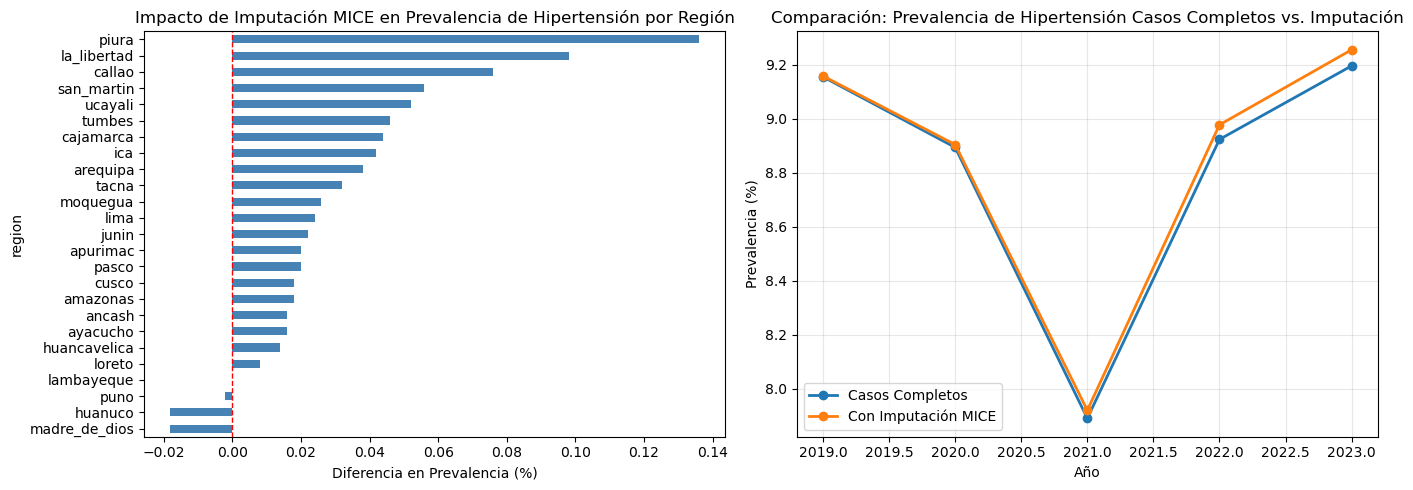


Tabla de análisis de sensibilidad exportada a: sensitivity_analysis_hipertension.csv


In [153]:
# Gráfico de comparación: prevalencia con y sin imputación
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Diferencia de prevalencia por región
diff_by_region = sensitivity_analysis.groupby("region")["diferencia_prevalencia"].mean().sort_values()
diff_by_region.plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_xlabel("Diferencia en Prevalencia (%)")
axes[0].set_title("Impacto de Imputación MICE en Prevalencia de Hipertensión por Región")
axes[0].axvline(0, color="red", linestyle="--", linewidth=1)

# Gráfico 2: Comparación por año
comparison_year = sensitivity_analysis.groupby("anio").agg({
    "prevalencia_completos": "mean",
    "prevalencia_imputado": "mean"
})
comparison_year.plot(ax=axes[1], marker="o", linewidth=2)
axes[1].set_xlabel("Año")
axes[1].set_ylabel("Prevalencia (%)")
axes[1].set_title("Comparación: Prevalencia de Hipertensión Casos Completos vs. Imputación")
axes[1].legend(["Casos Completos", "Con Imputación MICE"], loc="best")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Exportar tabla de sensibilidad
sensitivity_analysis.to_csv("sensitivity_analysis_hipertension.csv", index=False)
print("\nTabla de análisis de sensibilidad exportada a: sensitivity_analysis_hipertension.csv")

In [154]:
# Estadísticas resumen del análisis de sensibilidad
print("=== ANÁLISIS DE SENSIBILIDAD ===")
print(f"\nDiferencia promedio de prevalencia: {sensitivity_analysis['diferencia_prevalencia'].mean():.2f}%")
print(f"Desv. Est. de diferencias: {sensitivity_analysis['diferencia_prevalencia'].std():.2f}%")
print(f"Mín diferencia: {sensitivity_analysis['diferencia_prevalencia'].min():.2f}%")
print(f"Máx diferencia: {sensitivity_analysis['diferencia_prevalencia'].max():.2f}%")

# Regiones con mayor impacto
print("\nTop 5 regiones con mayor impacto de imputación:")
print(sensitivity_analysis.nlargest(5, "diferencia_prevalencia")[["region", "anio", "diferencia_prevalencia"]])

=== ANÁLISIS DE SENSIBILIDAD ===

Diferencia promedio de prevalencia: 0.03%
Desv. Est. de diferencias: 0.07%
Mín diferencia: -0.07%
Máx diferencia: 0.31%

Top 5 regiones con mayor impacto de imputación:
      region  anio  diferencia_prevalencia
118   tumbes  2022                    0.31
99     piura  2023                    0.30
34    callao  2023                    0.26
124  ucayali  2023                    0.25
97     piura  2021                    0.22


# Correlaciones y asociaciones

## Correlación

### Matriz

<Axes: >

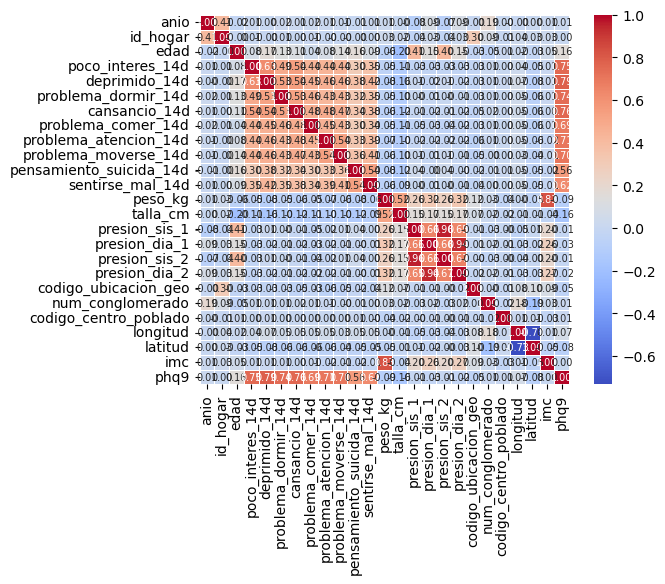

In [155]:
coor_matrix = salud.corr(numeric_only=True)

sns.heatmap(coor_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5, annot_kws={"size": 7})

### Columnas altamente correlacionadas para el Modelo 1

* peso_kg
* talla_cm

### Columnas altamente correlacionadas para el Modelo 2

* edad (prueba VIF)
* peso_kg (Prueba VIF)
* presion_sis_1
* presion_dia_1
* presion_sis_2
* presion_dia_2

## Asociación

### Anova y ETA

In [156]:
# eliminar filas con algún valor nan
salud_completo = salud.dropna()
salud_completo

,anio,id_hogar,cod_resultado,cod_persona,sexo,edad,diagnostico_hipertension,poco_interes_14d,deprimido_14d,problema_dormir_14d,...,area_residencia,lugar_residencia,codigo_ubicacion_geo,num_conglomerado,codigo_centro_poblado,nombre_centro_poblado,longitud,latitud,imc,phq9
0,2019,100201,completa,2,mujer,33.0,no,0.0,0.0,0.0,...,urbano,pequena_ciudad,10101,7065,1,chachapoyas,-77.87383,-6.223320,26.355556,0.0
1,2019,102801,completa,2,mujer,36.0,no,1.0,0.0,0.0,...,urbano,pequena_ciudad,10101,7065,1,chachapoyas,-77.87383,-6.223320,32.724838,1.0
2,2019,104801,completa,2,mujer,28.0,no,0.0,0.0,0.0,...,urbano,pequena_ciudad,10101,7065,1,chachapoyas,-77.87383,-6.223320,34.132280,0.0
3,2019,113601,completa,2,mujer,30.0,no,1.0,1.0,0.0,...,urbano,pequena_ciudad,10101,7065,1,chachapoyas,-77.87383,-6.223320,24.638117,3.0
5,2019,116701,completa,1,mujer,18.0,no,0.0,0.0,0.0,...,urbano,pequena_ciudad,10101,7065,1,chachapoyas,-77.87383,-6.223320,19.086083,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37478,2023,542901901,completa,2,mujer,71.0,no,0.0,1.0,3.0,...,rural,campo,180202,4381201,1,chojata,-70.73015,-16.388538,26.104897,7.0
37480,2023,542903101,completa,1,hombre,64.0,no,0.0,0.0,0.0,...,rural,campo,180202,4381201,1,chojata,-70.73015,-16.388538,24.533033,0.0
37482,2023,542904501,completa,2,mujer,56.0,no,0.0,0.0,0.0,...,rural,campo,180202,4381201,1,chojata,-70.73015,-16.388538,25.117073,1.0
37483,2023,542904701,completa,1,hombre,67.0,si,3.0,3.0,0.0,...,rural,campo,180202,4381201,1,chojata,-70.73015,-16.388538,26.770831,9.0


In [157]:
col_cat = [ 
    'sexo', 
    'diagnostico_hipertension',
    'poco_interes_14d', 
    'deprimido_14d',
    'problema_dormir_14d', 'cansancio_14d', 'problema_comer_14d',
    'problema_atencion_14d', 'problema_moverse_14d',
    'pensamiento_suicida_14d', 'sentirse_mal_14d',
    'region', 'area_residencia', 'lugar_residencia', 'nombre_centro_poblado'
]

In [158]:
col_num_1 = [
    "peso_kg",
    "talla_cm",
]

col_num_2 = [
    "presion_sis_1",
    "presion_dia_1",
    "presion_sis_2",
    "presion_dia_2"
]

In [159]:
from scipy.stats import f_oneway

#funcion para realizar el test de ANOVA para cada columna categórica
def anova_test(df, col_cat, col_num_1, col_num_2):
    anova_results = {
        "col_num_1": {col_num: {} for col_num in col_num_1},
        "col_num_2": {col_num: {} for col_num in col_num_2}
    }

    for col in col_cat:
        for col_num in col_num_1:
            groups = df.groupby(col)[col_num].apply(list)
            anova = f_oneway(*groups)
            anova_results["col_num_1"][col_num][col] = anova

        for col_num in col_num_2:
            groups = df.groupby(col)[col_num].apply(list)
            anova = f_oneway(*groups)
            anova_results["col_num_2"][col_num][col] = anova

    return anova_results

In [160]:
#realizar el test de ANOVA
anova_results = anova_test(salud_completo, col_cat, col_num_1, col_num_2)

In [161]:
#función que retorne los resultados del test de ANOVA con p-valor menor a 0.05
# Filtrar ANOVA significativos con p < 0.05
def anova_significativos(anova_results):
    anova_sig = {
        "col_num_1": {},
        "col_num_2": {}
    }
    
    for key in ["col_num_1", "col_num_2"]:
        for col_num, results in anova_results[key].items():
            anova_sig[key][col_num] = {col: res for col, res in results.items() if res.pvalue < 0.05}
    
    return anova_sig

In [162]:
# Filtrar variables significativas
anova_sig = anova_significativos(anova_results)

In [163]:
# Función para calcular eta-cuadrado solo en los ANOVA significativos
def eta_cuadrado(df, anova_significativos):
    eta_results = {
        "col_num_1": {},
        "col_num_2": {}
    }

    for key in ["col_num_1", "col_num_2"]:
        for col_num, results in anova_significativos[key].items():
            for col in results.keys():
                ss_total = sum((df[col_num] - df[col_num].mean())**2)
                ss_between = sum([len(group) * (group.mean() - df[col_num].mean())**2 for _, group in df.groupby(col)[col_num]])
                eta_results[key].setdefault(col_num, {})[col] = ss_between / ss_total
    
    return eta_results

In [164]:
# Calcular eta-cuadrado solo en las variables significativas
eta_results = eta_cuadrado(salud_completo, anova_sig)

# Ver resultados
eta_results

{'col_num_1': {'peso_kg': {'sexo': np.float64(0.07472636338329618),
   'diagnostico_hipertension': np.float64(0.0024082999495026653),
   'poco_interes_14d': np.float64(0.0029002115583479865),
   'deprimido_14d': np.float64(0.00791188445333704),
   'problema_dormir_14d': np.float64(0.003058175199048911),
   'cansancio_14d': np.float64(0.004723055313245842),
   'problema_comer_14d': np.float64(0.0033662556458429033),
   'problema_atencion_14d': np.float64(0.006108920185718255),
   'problema_moverse_14d': np.float64(0.004358946011048213),
   'pensamiento_suicida_14d': np.float64(0.00663424255071543),
   'sentirse_mal_14d': np.float64(0.005099062241711923),
   'region': np.float64(0.06702979597488334),
   'area_residencia': np.float64(0.053565254304878705),
   'lugar_residencia': np.float64(0.05590920469921077),
   'nombre_centro_poblado': np.float64(0.13395106014075492)},
  'talla_cm': {'sexo': np.float64(0.46748497879914325),
   'diagnostico_hipertension': np.float64(0.006285975151951178

### Columnas ETA > 0.05 para el Modelo 1

* sexo
* nombre_centro_poblado
* region
* area_residencia
* lugar_residencia

### Columnas ETA > 0.05 para el Modelo 2

* sexo
* diagnostico_hipertension
* nombre_centro_poblado

# Modelos de imputación

In [165]:
salud_completo

,anio,id_hogar,cod_resultado,cod_persona,sexo,edad,diagnostico_hipertension,poco_interes_14d,deprimido_14d,problema_dormir_14d,...,area_residencia,lugar_residencia,codigo_ubicacion_geo,num_conglomerado,codigo_centro_poblado,nombre_centro_poblado,longitud,latitud,imc,phq9
0,2019,100201,completa,2,mujer,33.0,no,0.0,0.0,0.0,...,urbano,pequena_ciudad,10101,7065,1,chachapoyas,-77.87383,-6.223320,26.355556,0.0
1,2019,102801,completa,2,mujer,36.0,no,1.0,0.0,0.0,...,urbano,pequena_ciudad,10101,7065,1,chachapoyas,-77.87383,-6.223320,32.724838,1.0
2,2019,104801,completa,2,mujer,28.0,no,0.0,0.0,0.0,...,urbano,pequena_ciudad,10101,7065,1,chachapoyas,-77.87383,-6.223320,34.132280,0.0
3,2019,113601,completa,2,mujer,30.0,no,1.0,1.0,0.0,...,urbano,pequena_ciudad,10101,7065,1,chachapoyas,-77.87383,-6.223320,24.638117,3.0
5,2019,116701,completa,1,mujer,18.0,no,0.0,0.0,0.0,...,urbano,pequena_ciudad,10101,7065,1,chachapoyas,-77.87383,-6.223320,19.086083,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37478,2023,542901901,completa,2,mujer,71.0,no,0.0,1.0,3.0,...,rural,campo,180202,4381201,1,chojata,-70.73015,-16.388538,26.104897,7.0
37480,2023,542903101,completa,1,hombre,64.0,no,0.0,0.0,0.0,...,rural,campo,180202,4381201,1,chojata,-70.73015,-16.388538,24.533033,0.0
37482,2023,542904501,completa,2,mujer,56.0,no,0.0,0.0,0.0,...,rural,campo,180202,4381201,1,chojata,-70.73015,-16.388538,25.117073,1.0
37483,2023,542904701,completa,1,hombre,67.0,si,3.0,3.0,0.0,...,rural,campo,180202,4381201,1,chojata,-70.73015,-16.388538,26.770831,9.0


## Modelo 1 (peso y talla)

### Regresión múltiple

In [166]:
#columnas categóricas 
col_cat = [
    "sexo",
    #"nombre_centro_poblado",
    "region",
    "area_residencia",
    "lugar_residencia"
]

#columnas numéricas
col_num = [
    "peso_kg",
    "talla_cm"
]

In [167]:
salud_completo[col_cat].nunique()

sexo                 2
region              25
area_residencia      2
lugar_residencia     4
dtype: int64

In [168]:
#variables dummy
cat_dummies = pd.get_dummies(salud_completo[col_cat], drop_first=True)

In [169]:
#unir cat_dummies con las columnas numéricas
df_modelo_1 = pd.concat([salud_completo[col_num], cat_dummies], axis=1)
df_modelo_1

,peso_kg,talla_cm,sexo_mujer,region_ancash,region_apurimac,region_arequipa,region_ayacucho,region_cajamarca,region_callao,region_cusco,...,region_piura,region_puno,region_san_martin,region_tacna,region_tumbes,region_ucayali,area_residencia_urbano,lugar_residencia_capital_gran_ciudad,lugar_residencia_pequena_ciudad,lugar_residencia_pueblo
0,59.3,150.0,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
1,84.3,160.5,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
2,85.1,157.9,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
3,57.6,152.9,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
5,45.5,154.4,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37478,57.8,148.8,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
37480,62.1,159.1,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
37482,52.3,144.3,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
37483,67.0,158.2,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [170]:
#funcion que defina X y Y para que Y1 sea peso_kg y Y2 sea talla_cm

def definir_X_Y(df):
    X1 = df.drop(["peso_kg", "talla_cm"], axis=1)
    Y1 = df["peso_kg"]
    X2 = df.drop(["peso_kg", "talla_cm"], axis=1)
    Y2 = df["talla_cm"]
    return X1, Y1, X2, Y2

In [171]:
# usar la función definir_X_Y
X1, Y1, X2, Y2 = definir_X_Y(df_modelo_1)

In [172]:
import statsmodels.api as sm
#función para definir interceptos
def add_intercept(X):
    X = sm.add_constant(X)
    return X

In [173]:
#definir interceptos
X1 = add_intercept(X1)
X2 = add_intercept(X2)

In [174]:
# Asegurar que X y Y sean numéricos y estén alineados; eliminar filas con valores no numéricos o NA
X1_clean = X1.apply(pd.to_numeric, errors="coerce")
X2_clean = X2.apply(pd.to_numeric, errors="coerce")
Y1_clean = pd.to_numeric(Y1, errors="coerce")
Y2_clean = pd.to_numeric(Y2, errors="coerce")

df1 = pd.concat([Y1_clean, X1_clean], axis=1)
df2 = pd.concat([Y2_clean, X2_clean], axis=1)

# eliminar filas con NA (coerción anterior convierte no-numéricos a NaN)
df1 = df1.dropna()
df2 = df2.dropna()

Y1_final = df1.iloc[:, 0].astype(float)
X1_final = df1.iloc[:, 1:].astype(float)
Y2_final = df2.iloc[:, 0].astype(float)
X2_final = df2.iloc[:, 1:].astype(float)

# Verificar que no queden columnas no-numéricas y mostrar si las hay
non_num_X1 = X1_final.select_dtypes(exclude=[np.number]).columns.tolist()
non_num_X2 = X2_final.select_dtypes(exclude=[np.number]).columns.tolist()
if non_num_X1 or non_num_X2:
	print("Columnas no-numéricas en X1_final:", non_num_X1)
	print("Columnas no-numéricas en X2_final:", non_num_X2)
	raise ValueError("Existen columnas no numéricas en las matrices de diseño. Revisa la conversión.")

# Añadir constante si no existe (sm.add_constant con has_constant='skip' evita duplicados)
X1_final = sm.add_constant(X1_final, has_constant="skip")
X2_final = sm.add_constant(X2_final, has_constant="skip")

# Ajustar modelos
ml_peso = sm.OLS(Y1_final, X1_final).fit()
ml_talla = sm.OLS(Y2_final, X2_final).fit()

In [175]:
print(ml_peso.summary())

                            OLS Regression Results                            
Dep. Variable:                peso_kg   R-squared:                       0.162
Model:                            OLS   Adj. R-squared:                  0.162
Method:                 Least Squares   F-statistic:                     970.9
Date:                Fri, 28 Nov 2025   Prob (F-statistic):               0.00
Time:                        19:32:19   Log-Likelihood:            -5.5368e+05
No. Observations:              140423   AIC:                         1.107e+06
Df Residuals:                  140394   BIC:                         1.108e+06
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


In [176]:
# ====== ANÁLISIS DE LIMITACIONES DEL MODELO IMC ======

print("=" * 60)
print("CAPACIDAD PREDICTIVA DEL MODELO DE IMPUTACIÓN IMC")
print("=" * 60)

# Extraer R² de los modelos
r2_peso = ml_peso.rsquared
r2_talla = ml_talla.rsquared
r2_promedio = (r2_peso + r2_talla) / 2

print(f"\nMétrica de Bondad de Ajuste (R²):")
print(f"  - Modelo Peso (kg):     {r2_peso:.4f}")
print(f"  - Modelo Talla (cm):    {r2_talla:.4f}")
print(f"  - Promedio:             {r2_promedio:.4f}")

CAPACIDAD PREDICTIVA DEL MODELO DE IMPUTACIÓN IMC

Métrica de Bondad de Ajuste (R²):
  - Modelo Peso (kg):     0.1622
  - Modelo Talla (cm):    0.5031
  - Promedio:             0.3327


In [177]:
# SENSIBILIDAD IMC: Casos Completos vs. Imputados

# Dataset con IMC observado (completo)
salud_imc_completo = salud.dropna(subset=["peso_kg", "talla_cm"])
salud_imc_completo["imc_observado"] = salud_imc_completo["peso_kg"] / (salud_imc_completo["talla_cm"] / 100) ** 2

# Dataset con IMC imputado
salud_imc_imputado = salud.copy()
salud_imc_imputado["imc_imputado"] = salud_imc_imputado["peso_kg"] / (salud_imc_imputado["talla_cm"] / 100) ** 2

# Comparación por región
imc_comparison = salud_imc_completo.groupby("region").agg({
    "imc_observado": ["mean", "std", "min", "max"]
}).round(2)

imc_imputado_comparison = salud_imc_imputado.groupby("region").agg({
    "imc_imputado": ["mean", "std", "min", "max"]
}).round(2)

print("IMC OBSERVADO (sin imputación):")
print(imc_comparison)
print("\nIMC IMPUTADO (con regresión débil):")
print(imc_imputado_comparison)

# Diferencia de medias por región
diff_imc = (
    salud_imc_imputado.groupby("region")["imc_imputado"].mean() - 
    salud_imc_completo.groupby("region")["imc_observado"].mean()
).round(2)

print("\nDIFERENCIA de IMC medio (Imputado - Observado) por región:")
print(diff_imc.sort_values(ascending=False))

IMC OBSERVADO (sin imputación):
              imc_observado                    
                       mean   std    min    max
region                                         
amazonas              26.23  4.16  15.26  48.91
ancash                27.34  4.60  13.32  68.79
apurimac              26.04  4.08  15.91  49.67
arequipa              27.87  4.73  14.84  51.70
ayacucho              26.36  4.24  16.34  50.04
cajamarca             26.38  3.96  14.48  52.62
callao                28.44  5.20  15.74  68.79
cusco                 26.38  4.40  13.48  61.37
huancavelica          25.42  3.88  14.82  50.70
huanuco               26.28  4.40  14.07  57.88
ica                   28.74  5.15  12.76  72.89
junin                 26.57  4.32  15.77  48.97
la_libertad           27.62  4.83  15.18  62.41
lambayeque            27.58  4.62  15.02  67.90
lima                  28.21  5.01  14.69  60.11
loreto                26.91  4.67  13.84  48.85
madre_de_dios         28.70  5.03  14.96  59.48
moquegua

In [178]:
print(ml_talla.summary())

                            OLS Regression Results                            
Dep. Variable:               talla_cm   R-squared:                       0.503
Model:                            OLS   Adj. R-squared:                  0.503
Method:                 Least Squares   F-statistic:                     5077.
Date:                Fri, 28 Nov 2025   Prob (F-statistic):               0.00
Time:                        19:32:20   Log-Likelihood:            -4.5426e+05
No. Observations:              140423   AIC:                         9.086e+05
Df Residuals:                  140394   BIC:                         9.089e+05
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


### VIF

In [179]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# función para calcular el VIF
def calculate_vif(X):
    vif_data = pd.DataFrame()
    vif_data["feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
    return vif_data

In [180]:
# Calcular el VIF usando la matriz de diseño final (numérica) X1_final
# VIF requiere entradas numéricas y finitas; intentamos usar X1_final (creada y limpiada antes).
try:
	vif_matrix = calculate_vif(X1_final)
except NameError:
	# Si X1_final no está disponible, intentar con X1_clean si existe
	if "X1_clean" in globals():
		vif_matrix = calculate_vif(X1_clean.dropna())
	else:
		# Como último recurso convertir X1 a numérico, eliminar filas/columnas no numéricas/NaN y calcular VIF
		X1_numeric = X1.apply(pd.to_numeric, errors="coerce")
		# eliminar columnas totalmente NaN y filas con NaN
		X1_numeric = X1_numeric.dropna(axis=1, how="all").dropna(axis=0, how="any")
		vif_matrix = calculate_vif(X1_numeric)

vif_matrix

,feature,VIF
0,const,26.422960
1,sexo_mujer,1.002772
2,region_ancash,1.824700
3,region_apurimac,1.838581
4,region_arequipa,1.849126
5,region_ayacucho,1.969688
6,region_cajamarca,1.845270
7,region_callao,3.094524
8,region_cusco,1.784758
9,region_huancavelica,1.867690


In [181]:
# Calcular el VIF para talla_cm (limpiar X2 antes de calcular)
# 1) Convertir a numérico (coerce), 2) eliminar columnas con NaN, 3) eliminar columnas constantes o no finitas
X2_numeric = X2.copy().apply(pd.to_numeric, errors="coerce")

# Eliminar columnas que contienen NaN (VIF requiere datos completos)
X2_complete = X2_numeric.dropna(axis=1, how="any")

# Eliminar columnas con valores no finitos
finite_mask = X2_complete.apply(lambda col: np.isfinite(col).all())
X2_finite = X2_complete.loc[:, finite_mask]

# Eliminar columnas constantes (var == 0)
non_const_mask = X2_finite.var() != 0
X2_clean = X2_finite.loc[:, non_const_mask]

if X2_clean.shape[1] == 0:
	print("No hay columnas numéricas finitas y no constantes en X2 para calcular VIF. Revisa X2.")
else:
	vif_talla = calculate_vif(X2_clean)
	print(vif_talla)

                                 feature       VIF
0                             sexo_mujer  0.000028
1                          region_ancash  0.000219
2                        region_apurimac  0.000204
3                        region_arequipa  0.000247
4                        region_ayacucho  0.000183
5                       region_cajamarca  0.000202
6                          region_callao  0.000520
7                           region_cusco  0.000222
8                    region_huancavelica  0.000196
9                         region_huanuco  0.000188
10                            region_ica  0.000240
11                          region_junin  0.000222
12                    region_la_libertad  0.000233
13                     region_lambayeque  0.000228
14                           region_lima  0.000223
15                         region_loreto  0.000227
16                  region_madre_de_dios  0.000237
17                       region_moquegua  0.000239
18                          reg

### Modelo de regresión lineal múltiple

In [182]:
# obtener las filas con al menos un valor nan en peso_kg o talla_cm en salud
salud_nan = salud[salud["peso_kg"].isna() | salud["talla_cm"].isna()]
salud_nan

,anio,id_hogar,cod_resultado,cod_persona,sexo,edad,diagnostico_hipertension,poco_interes_14d,deprimido_14d,problema_dormir_14d,...,area_residencia,lugar_residencia,codigo_ubicacion_geo,num_conglomerado,codigo_centro_poblado,nombre_centro_poblado,longitud,latitud,imc,phq9
9314,2019,78305001,completa,2,mujer,47.0,si,1.0,1.0,1.0,...,urbano,pequena_ciudad,140106,3913,1,la victoria,-79.835690,-6.793030,NaN,4.0
9013,2020,115007601,completa,1,hombre,42.0,no,0.0,0.0,0.0,...,rural,campo,170103,39052,13,fray martin de porras,-69.134653,-12.025647,NaN,0.0
12999,2020,166111601,completa,4,mujer,23.0,no,0.0,0.0,0.0,...,rural,campo,10704,6656,4,san pedro,-78.572144,-5.595241,NaN,0.0
16444,2020,193916201,completa,1,hombre,31.0,no,0.0,0.0,0.0,...,rural,campo,60602,5012,70,san juan de chiple,-78.898777,-6.048817,NaN,0.0
16606,2020,195004101,completa,3,mujer,74.0,si,2.0,1.0,2.0,...,rural,campo,61109,5734,1,niepos,-79.128410,-6.926730,NaN,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36597,2023,535001301,completa,2,mujer,47.0,no,0.0,0.0,1.0,...,urbano,pequena_ciudad,220901,9462,1,tarapoto,-76.361859,-6.492003,NaN,4.0
36861,2023,537302901,completa,2,mujer,34.0,no,0.0,0.0,0.0,...,urbano,pequena_ciudad,230101,44469,1,tacna,-70.244233,-18.012357,NaN,0.0
37077,2023,539306301,completa,4,hombre,80.0,no,2.0,2.0,2.0,...,urbano,pequena_ciudad,240101,12301,1,tumbes,-80.447325,-3.561551,NaN,18.0
37189,2023,540404401,completa,2,mujer,31.0,no,1.0,1.0,1.0,...,urbano,pueblo,240302,335,2,la curva,-80.261501,-3.490453,NaN,7.0


In [183]:
# convertir a dummy las columnas categóricas
cat_dummies_nan = pd.get_dummies(salud_nan[col_cat], drop_first=True)

In [184]:
#unir cat_dummies_nan con las columnas numéricas
df_prueba_1 = pd.concat([salud_nan[col_num], cat_dummies_nan], axis=1)
df_prueba_1

,peso_kg,talla_cm,sexo_mujer,region_ancash,region_apurimac,region_arequipa,region_ayacucho,region_cajamarca,region_callao,region_cusco,...,region_piura,region_puno,region_san_martin,region_tacna,region_tumbes,region_ucayali,area_residencia_urbano,lugar_residencia_capital_gran_ciudad,lugar_residencia_pequena_ciudad,lugar_residencia_pueblo
9314,NaN,NaN,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
9013,NaN,NaN,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
12999,NaN,NaN,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
16444,NaN,NaN,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
16606,NaN,NaN,True,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36597,NaN,NaN,True,False,False,False,False,False,False,False,...,False,False,True,False,False,False,True,False,True,False
36861,NaN,NaN,True,False,False,False,False,False,False,False,...,False,False,False,True,False,False,True,False,True,False
37077,NaN,NaN,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,True,False,True,False
37189,NaN,NaN,True,False,False,False,False,False,False,False,...,False,False,False,False,True,False,True,False,False,True


In [185]:
# función que impute los valores nan de salud_nan con ml_peso y ml_talla
def imputar_nan(df, ml_peso, ml_talla):
    df_imputado = df.copy()
    df_imputado["peso_kg"] = ml_peso.predict(df_imputado.drop(["peso_kg", "talla_cm"], axis=1))
    df_imputado["talla_cm"] = ml_talla.predict(df_imputado.drop(["peso_kg", "talla_cm"], axis=1))
    
    return df_imputado  

In [186]:
# Añadir la columna de intercepto a df_prueba_1
df_prueba_1 = add_intercept(df_prueba_1)

#imputar los valores nan
df_prueba_imputado = imputar_nan(df_prueba_1, ml_peso, ml_talla)
df_prueba_imputado

,const,peso_kg,talla_cm,sexo_mujer,region_ancash,region_apurimac,region_arequipa,region_ayacucho,region_cajamarca,region_callao,...,region_piura,region_puno,region_san_martin,region_tacna,region_tumbes,region_ucayali,area_residencia_urbano,lugar_residencia_capital_gran_ciudad,lugar_residencia_pequena_ciudad,lugar_residencia_pueblo
9314,1.0,66.140137,153.255753,True,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
9013,1.0,71.840923,162.305619,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
12999,1.0,59.009986,150.097388,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
16444,1.0,66.603882,161.517971,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
16606,1.0,58.97704,149.408276,True,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36597,1.0,65.826782,153.509216,True,False,False,False,False,False,False,...,False,False,True,False,False,False,True,False,True,False
36861,1.0,71.298828,154.50563,True,False,False,False,False,False,False,...,False,False,False,True,False,False,True,False,True,False
37077,1.0,76.460815,166.844391,False,False,False,False,False,False,False,...,False,False,False,False,True,False,True,False,True,False
37189,1.0,68.337891,153.805008,True,False,False,False,False,False,False,...,False,False,False,False,True,False,True,False,False,True


In [187]:
#seleccionar las columnas peso_kg y talla_cm de df_prueba_imputado
df_prueba_imputado = df_prueba_imputado[["peso_kg", "talla_cm"]]
df_prueba_imputado

,peso_kg,talla_cm
9314,66.140137,153.255753
9013,71.840923,162.305619
12999,59.009986,150.097388
16444,66.603882,161.517971
16606,58.97704,149.408276
...,...,...
36597,65.826782,153.509216
36861,71.298828,154.50563
37077,76.460815,166.844391
37189,68.337891,153.805008


In [188]:
#completar solo los valores nan de salud con los valores imputados de df_prueba_imputado según el índice
salud.loc[df_prueba_imputado.index, ["peso_kg", "talla_cm"]] = df_prueba_imputado
salud

,anio,id_hogar,cod_resultado,cod_persona,sexo,edad,diagnostico_hipertension,poco_interes_14d,deprimido_14d,problema_dormir_14d,...,area_residencia,lugar_residencia,codigo_ubicacion_geo,num_conglomerado,codigo_centro_poblado,nombre_centro_poblado,longitud,latitud,imc,phq9
0,2019,100201,completa,2,mujer,33.0,no,0.0,0.0,0.0,...,urbano,pequena_ciudad,10101,7065,1,chachapoyas,-77.87383,-6.223320,26.355556,0.0
1,2019,102801,completa,2,mujer,36.0,no,1.0,0.0,0.0,...,urbano,pequena_ciudad,10101,7065,1,chachapoyas,-77.87383,-6.223320,32.724838,1.0
2,2019,104801,completa,2,mujer,28.0,no,0.0,0.0,0.0,...,urbano,pequena_ciudad,10101,7065,1,chachapoyas,-77.87383,-6.223320,34.132280,0.0
3,2019,113601,completa,2,mujer,30.0,no,1.0,1.0,0.0,...,urbano,pequena_ciudad,10101,7065,1,chachapoyas,-77.87383,-6.223320,24.638117,3.0
5,2019,116701,completa,1,mujer,18.0,no,0.0,0.0,0.0,...,urbano,pequena_ciudad,10101,7065,1,chachapoyas,-77.87383,-6.223320,19.086083,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37478,2023,542901901,completa,2,mujer,71.0,no,0.0,1.0,3.0,...,rural,campo,180202,4381201,1,chojata,-70.73015,-16.388538,26.104897,7.0
37480,2023,542903101,completa,1,hombre,64.0,no,0.0,0.0,0.0,...,rural,campo,180202,4381201,1,chojata,-70.73015,-16.388538,24.533033,0.0
37482,2023,542904501,completa,2,mujer,56.0,no,0.0,0.0,0.0,...,rural,campo,180202,4381201,1,chojata,-70.73015,-16.388538,25.117073,1.0
37483,2023,542904701,completa,1,hombre,67.0,si,3.0,3.0,0.0,...,rural,campo,180202,4381201,1,chojata,-70.73015,-16.388538,26.770831,9.0


## Modelo 2 (presiones)

### Random forest

In [189]:
#columnas categóricas
col_cat = [
    "sexo",
    "diagnostico_hipertension",
    "region",
    #"nombre_centro_poblado"
]

#columnas numéricas
col_num = [
    "presion_sis_1",
    "presion_dia_1",
    "presion_sis_2",
    "presion_dia_2",
    "edad",
    "peso_kg"
]

In [190]:
salud_completo[col_cat].nunique()

sexo                         2
diagnostico_hipertension     2
region                      25
dtype: int64

In [191]:
#variables dummy
cat_dummies = pd.get_dummies(salud_completo[col_cat], drop_first=True)

In [192]:
#unir cat_dummies con las columnas numéricas
df_modelo_2 = pd.concat([salud_completo[col_num], cat_dummies], axis=1)
df_modelo_2

,presion_sis_1,presion_dia_1,presion_sis_2,presion_dia_2,edad,peso_kg,sexo_mujer,diagnostico_hipertension_si,region_ancash,region_apurimac,...,region_loreto,region_madre_de_dios,region_moquegua,region_pasco,region_piura,region_puno,region_san_martin,region_tacna,region_tumbes,region_ucayali
0,97.0,62.0,102.0,59.0,33.0,59.3,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,115.0,75.0,106.0,75.0,36.0,84.3,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,135.0,74.0,133.0,77.0,28.0,85.1,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,102.0,69.0,95.0,61.0,30.0,57.6,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,123.0,74.0,112.0,70.0,18.0,45.5,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37478,139.0,80.0,129.0,77.0,71.0,57.8,True,False,False,False,...,False,False,True,False,False,False,False,False,False,False
37480,117.0,82.0,112.0,81.0,64.0,62.1,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
37482,107.0,75.0,106.0,76.0,56.0,52.3,True,False,False,False,...,False,False,True,False,False,False,False,False,False,False
37483,126.0,78.0,130.0,81.0,67.0,67.0,False,True,False,False,...,False,False,True,False,False,False,False,False,False,False


In [193]:
#función para definir train_test_split para presion_sis_1, presion_dia_1, presion_sis_2 y presion_dia_2
from sklearn.model_selection import train_test_split

def train_test_split_presion(df):
    X = df.drop(["presion_sis_1", "presion_dia_1", "presion_sis_2", "presion_dia_2"], axis=1)
    Y_presion_sis_1 = df["presion_sis_1"]
    Y_presion_dia_1 = df["presion_dia_1"]
    Y_presion_sis_2 = df["presion_sis_2"]
    Y_presion_dia_2 = df["presion_dia_2"]
    
    X_train, X_test, Y_train_presion_sis_1, Y_test_presion_sis_1 = train_test_split(X, Y_presion_sis_1, test_size=0.2, random_state=42)
    X_train, X_test, Y_train_presion_dia_1, Y_test_presion_dia_1 = train_test_split(X, Y_presion_dia_1, test_size=0.2, random_state=42)
    X_train, X_test, Y_train_presion_sis_2, Y_test_presion_sis_2 = train_test_split(X, Y_presion_sis_2, test_size=0.2, random_state=42)
    X_train, X_test, Y_train_presion_dia_2, Y_test_presion_dia_2 = train_test_split(X, Y_presion_dia_2, test_size=0.2, random_state=42)
    
    return X_train, X_test, Y_train_presion_sis_1, Y_test_presion_sis_1, Y_train_presion_dia_1, Y_test_presion_dia_1, Y_train_presion_sis_2, Y_test_presion_sis_2, Y_train_presion_dia_2, Y_test_presion_dia_2

In [194]:
#usar la función train_test_split_presion
X_train, X_test, Y_train_presion_sis_1, Y_test_presion_sis_1, Y_train_presion_dia_1, Y_test_presion_dia_1, Y_train_presion_sis_2, Y_test_presion_sis_2, Y_train_presion_dia_2, Y_test_presion_dia_2 = train_test_split_presion(df_modelo_2)

In [195]:
X_train

,edad,peso_kg,sexo_mujer,diagnostico_hipertension_si,region_ancash,region_apurimac,region_arequipa,region_ayacucho,region_cajamarca,region_callao,...,region_loreto,region_madre_de_dios,region_moquegua,region_pasco,region_piura,region_puno,region_san_martin,region_tacna,region_tumbes,region_ucayali
12764,83.0,83.8,False,True,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
265,39.0,81.6,True,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
24123,22.0,84.2,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
21418,63.0,40.1,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
33067,29.0,85.1,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36474,30.0,58.2,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
11343,47.0,62.2,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
28149,33.0,83.1,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
26671,42.0,57.9,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [196]:
#función para entrenar el modelo Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

def entrenar_modelo(X_train, Y_train):
    rf = RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        random_state=42,
        max_features="sqrt"
    )
    rf.fit(X_train, Y_train)
    return rf

In [197]:
#función para predecir con el modelo entrenado
def predecir_modelo(rf, X_test):
    Y_pred = rf.predict(X_test)
    return Y_pred

In [198]:
# Entrenar el modelo Random Forest Regressor para cada variable de presión
rf_presion_sis_1 = entrenar_modelo(X_train, Y_train_presion_sis_1)
rf_presion_dia_1 = entrenar_modelo(X_train, Y_train_presion_dia_1)
rf_presion_sis_2 = entrenar_modelo(X_train, Y_train_presion_sis_2)
rf_presion_dia_2 = entrenar_modelo(X_train, Y_train_presion_dia_2)

In [199]:
# Predecir con el modelo entrenado
Y_pred_presion_sis_1 = predecir_modelo(rf_presion_sis_1, X_test)
Y_pred_presion_dia_1 = predecir_modelo(rf_presion_dia_1, X_test)
Y_pred_presion_sis_2 = predecir_modelo(rf_presion_sis_2, X_test)
Y_pred_presion_dia_2 = predecir_modelo(rf_presion_dia_2, X_test)

In [200]:
Y_pred_presion_dia_2

array([70.88354518, 76.13263978, 67.23514843, ..., 69.56190115,
       75.4809661 , 71.07650996], shape=(28085,))

In [201]:
#definir función para calcular el MAE
from sklearn.metrics import mean_absolute_error

def calcular_mae(Y_test, Y_pred):
    mae = mean_absolute_error(Y_test, Y_pred)
    return mae

In [202]:
#calcular el MAE para cada variable de presión
mae_presion_sis_1 = calcular_mae(Y_test_presion_sis_1, Y_pred_presion_sis_1)
mae_presion_dia_1 = calcular_mae(Y_test_presion_dia_1, Y_pred_presion_dia_1)
mae_presion_sis_2 = calcular_mae(Y_test_presion_sis_2, Y_pred_presion_sis_2)
mae_presion_dia_2 = calcular_mae(Y_test_presion_dia_2, Y_pred_presion_dia_2)

mae_presion_sis_1, mae_presion_dia_1, mae_presion_sis_2, mae_presion_dia_2

(10.611440826917962, 7.315653609619558, 10.365936315385103, 7.264923109555311)

In [203]:
# función para calcular el coeficiente de determinación R2
from sklearn.metrics import r2_score

def calcular_r2(Y_test, Y_pred):
    r2 = r2_score(Y_test, Y_pred)
    return r2

In [204]:
#calcular el coeficiente de determinación R2 para cada variable de presión
r2_presion_sis_1 = calcular_r2(Y_test_presion_sis_1, Y_pred_presion_sis_1)
r2_presion_dia_1 = calcular_r2(Y_test_presion_dia_1, Y_pred_presion_dia_1)
r2_presion_sis_2 = calcular_r2(Y_test_presion_sis_2, Y_pred_presion_sis_2)
r2_presion_dia_2 = calcular_r2(Y_test_presion_dia_2, Y_pred_presion_dia_2)

r2_presion_sis_1, r2_presion_dia_1, r2_presion_sis_2, r2_presion_dia_2

(0.33582655587674903,
 0.17112357618852414,
 0.3339030283057416,
 0.17790624925926501)

### Modelo Random Forest

In [205]:
# obtener las filas con al menos un valor nan en presion_sis_1, presion_dia_1, presion_sis_2 o presion_dia_2 en salud
salud_nan = salud[salud["presion_sis_1"].isna() | salud["presion_dia_1"].isna() | salud["presion_sis_2"].isna() | salud["presion_dia_2"].isna()]
salud_nan

,anio,id_hogar,cod_resultado,cod_persona,sexo,edad,diagnostico_hipertension,poco_interes_14d,deprimido_14d,problema_dormir_14d,...,area_residencia,lugar_residencia,codigo_ubicacion_geo,num_conglomerado,codigo_centro_poblado,nombre_centro_poblado,longitud,latitud,imc,phq9
8329,2020,105705101,completa,4,mujer,36.0,no,0.0,0.0,0.0,...,urbano,pequena_ciudad,160101,7647,1,iquitos,-73.255520,-3.752740,38.560348,0.0
14523,2020,177910701,completa,1,hombre,44.0,no,0.0,0.0,0.0,...,rural,campo,30214,36415,20,san isidro de tacta,-73.608747,-13.999867,24.367403,0.0
17069,2020,198710901,completa,2,mujer,40.0,no,2.0,1.0,0.0,...,urbano,capital_gran_ciudad,70106,17767,1,ventanilla,-77.125230,-11.848610,27.707470,4.0
21896,2020,238605901,completa,1,mujer,52.0,si,0.0,1.0,1.0,...,urbano,pequena_ciudad,140105,3725,1,jose leonardo ortiz,-79.817080,-6.753790,39.872542,2.0
23083,2020,248911601,completa,3,mujer,40.0,no,0.0,0.0,0.0,...,urbano,capital_gran_ciudad,150110,20890,1,la libertad,-77.039070,-11.935040,26.514003,0.0
23122,2020,249307701,completa,2,mujer,40.0,no,1.0,1.0,1.0,...,urbano,capital_gran_ciudad,150110,21078,1,la libertad,-77.068030,-11.945930,26.330717,4.0
30719,2020,314601502,completa,1,mujer,30.0,no,0.0,0.0,0.0,...,urbano,pequena_ciudad,240101,98,1,tumbes,-80.447810,-3.574170,35.555424,0.0
2211,2021,18002301,completa,2,mujer,37.0,no,0.0,1.0,1.0,...,urbano,pequena_ciudad,40102,42688,1,selva alegre,-71.520521,-16.369853,24.349636,2.0
3261,2021,27710101,completa,2,mujer,46.0,no,0.0,0.0,0.0,...,rural,campo,50108,35446,33,maisondo,-74.199827,-13.104153,21.588937,0.0
3295,2021,28000701,completa,2,mujer,28.0,no,0.0,0.0,0.0,...,rural,campo,50102,35494,33,santa barbara de uchuymarca,-74.012517,-13.333538,26.018572,0.0


In [206]:
salud_nan[col_cat].nunique()

sexo                         2
diagnostico_hipertension     2
region                      15
dtype: int64

In [207]:
#imprime los valores de region que tiene salud pero no salud_nan
salud[~salud["region"].isin(salud_nan["region"].unique())]["region"].unique()

array(['ancash', 'cusco', 'huancavelica', 'la_libertad', 'madre_de_dios',
       'moquegua', 'piura', 'puno', 'san_martin', 'ucayali'], dtype=object)

In [208]:
# Añadir filas muestreadas usando pd.concat (append está deprecado)
muestra = salud[salud["region"].isin([
    'ancash','cusco','huancavelica','la_libertad','madre_de_dios',
    'moquegua','piura','puno','san_martin','ucayali'
])].sample(30, random_state=42)

salud_nan = pd.concat([salud_nan, muestra])

In [209]:
salud_nan[col_cat].nunique()

sexo                         2
diagnostico_hipertension     2
region                      25
dtype: int64

In [210]:
#convertir a nan todos los valores de presion_sis_1, presion_dia_1, presion_sis_2 y presion_dia_2 en salud_nan
salud_nan["presion_sis_1"] = np.nan
salud_nan["presion_dia_1"] = np.nan
salud_nan["presion_sis_2"] = np.nan
salud_nan["presion_dia_2"] = np.nan
salud_nan

,anio,id_hogar,cod_resultado,cod_persona,sexo,edad,diagnostico_hipertension,poco_interes_14d,deprimido_14d,problema_dormir_14d,...,area_residencia,lugar_residencia,codigo_ubicacion_geo,num_conglomerado,codigo_centro_poblado,nombre_centro_poblado,longitud,latitud,imc,phq9
8329,2020,105705101,completa,4,mujer,36.0,no,0.0,0.0,0.0,...,urbano,pequena_ciudad,160101,7647,1,iquitos,-73.255520,-3.752740,38.560348,0.0
14523,2020,177910701,completa,1,hombre,44.0,no,0.0,0.0,0.0,...,rural,campo,30214,36415,20,san isidro de tacta,-73.608747,-13.999867,24.367403,0.0
17069,2020,198710901,completa,2,mujer,40.0,no,2.0,1.0,0.0,...,urbano,capital_gran_ciudad,70106,17767,1,ventanilla,-77.125230,-11.848610,27.707470,4.0
21896,2020,238605901,completa,1,mujer,52.0,si,0.0,1.0,1.0,...,urbano,pequena_ciudad,140105,3725,1,jose leonardo ortiz,-79.817080,-6.753790,39.872542,2.0
23083,2020,248911601,completa,3,mujer,40.0,no,0.0,0.0,0.0,...,urbano,capital_gran_ciudad,150110,20890,1,la libertad,-77.039070,-11.935040,26.514003,0.0
23122,2020,249307701,completa,2,mujer,40.0,no,1.0,1.0,1.0,...,urbano,capital_gran_ciudad,150110,21078,1,la libertad,-77.068030,-11.945930,26.330717,4.0
30719,2020,314601502,completa,1,mujer,30.0,no,0.0,0.0,0.0,...,urbano,pequena_ciudad,240101,98,1,tumbes,-80.447810,-3.574170,35.555424,0.0
2211,2021,18002301,completa,2,mujer,37.0,no,0.0,1.0,1.0,...,urbano,pequena_ciudad,40102,42688,1,selva alegre,-71.520521,-16.369853,24.349636,2.0
3261,2021,27710101,completa,2,mujer,46.0,no,0.0,0.0,0.0,...,rural,campo,50108,35446,33,maisondo,-74.199827,-13.104153,21.588937,0.0
3295,2021,28000701,completa,2,mujer,28.0,no,0.0,0.0,0.0,...,rural,campo,50102,35494,33,santa barbara de uchuymarca,-74.012517,-13.333538,26.018572,0.0


In [211]:
# convertir a dummy las columnas categóricas
cat_dummies_nan = pd.get_dummies(salud_nan[col_cat], drop_first=True)

In [212]:
#unir cat_dummies_nan con las columnas numéricas
df_prueba_2 = pd.concat([salud_nan[col_num], cat_dummies_nan], axis=1)

In [213]:
# función que impute los valores nan de salud_nan con rf_presion_sis_1, rf_presion_dia_1, rf_presion_sis_2 y rf_presion_dia_2
def imputar_nan_presion(df, rf_presion_sis_1, rf_presion_dia_1, rf_presion_sis_2, rf_presion_dia_2):
    df_imputado = df.copy()
    df_imputado["presion_sis_1"] = rf_presion_sis_1.predict(df_imputado.drop(["presion_sis_1", "presion_dia_1", "presion_sis_2", "presion_dia_2"], axis=1))
    df_imputado["presion_dia_1"] = rf_presion_dia_1.predict(df_imputado.drop(["presion_sis_1", "presion_dia_1", "presion_sis_2", "presion_dia_2"], axis=1))
    df_imputado["presion_sis_2"] = rf_presion_sis_2.predict(df_imputado.drop(["presion_sis_1", "presion_dia_1", "presion_sis_2", "presion_dia_2"], axis=1))
    df_imputado["presion_dia_2"] = rf_presion_dia_2.predict(df_imputado.drop(["presion_sis_1", "presion_dia_1", "presion_sis_2", "presion_dia_2"], axis=1))
    
    return df_imputado

In [214]:
#impotar los valores nan
df_prueba_imputado = imputar_nan_presion(df_prueba_2, rf_presion_sis_1, rf_presion_dia_1, rf_presion_sis_2, rf_presion_dia_2)
df_prueba_imputado

,presion_sis_1,presion_dia_1,presion_sis_2,presion_dia_2,edad,peso_kg,sexo_mujer,diagnostico_hipertension_si,region_ancash,region_apurimac,...,region_loreto,region_madre_de_dios,region_moquegua,region_pasco,region_piura,region_puno,region_san_martin,region_tacna,region_tumbes,region_ucayali
8329,115.742354,75.552796,113.891255,75.081503,36.0,93.6,True,False,False,False,...,True,False,False,False,False,False,False,False,False,False
14523,120.088591,74.807815,117.993544,74.160882,44.0,60.6,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
17069,115.842320,73.126703,113.886053,72.768729,40.0,65.2,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
21896,134.837868,83.374654,134.127326,81.226975,52.0,95.3,True,True,False,False,...,False,False,False,False,False,False,False,False,False,False
23083,113.120261,72.192081,111.461986,71.585295,40.0,61.5,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
23122,112.105533,71.856094,110.225649,71.096518,40.0,58.3,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
30719,114.009449,73.830719,112.057313,73.153246,30.0,81.5,True,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2211,109.691551,71.613306,107.972343,70.894135,37.0,58.5,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3261,112.417917,71.788880,110.791500,71.084762,46.0,51.4,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3295,109.395542,70.194226,107.263468,69.392985,28.0,63.4,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [215]:
#eliminar las últimas 30 filas de df_prueba_imputado
df_prueba_imputado = df_prueba_imputado[:-30]
df_prueba_imputado

,presion_sis_1,presion_dia_1,presion_sis_2,presion_dia_2,edad,peso_kg,sexo_mujer,diagnostico_hipertension_si,region_ancash,region_apurimac,...,region_loreto,region_madre_de_dios,region_moquegua,region_pasco,region_piura,region_puno,region_san_martin,region_tacna,region_tumbes,region_ucayali
8329,115.742354,75.552796,113.891255,75.081503,36.0,93.6,True,False,False,False,...,True,False,False,False,False,False,False,False,False,False
14523,120.088591,74.807815,117.993544,74.160882,44.0,60.6,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
17069,115.842320,73.126703,113.886053,72.768729,40.0,65.2,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
21896,134.837868,83.374654,134.127326,81.226975,52.0,95.3,True,True,False,False,...,False,False,False,False,False,False,False,False,False,False
23083,113.120261,72.192081,111.461986,71.585295,40.0,61.5,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
23122,112.105533,71.856094,110.225649,71.096518,40.0,58.3,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
30719,114.009449,73.830719,112.057313,73.153246,30.0,81.5,True,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2211,109.691551,71.613306,107.972343,70.894135,37.0,58.5,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3261,112.417917,71.788880,110.791500,71.084762,46.0,51.4,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3295,109.395542,70.194226,107.263468,69.392985,28.0,63.4,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [216]:
#seleccionar las columnas presion_sis_1, presion_dia_1, presion_sis_2 y presion_dia_2 de df_prueba_imputado
df_prueba_imputado = df_prueba_imputado[["presion_sis_1", "presion_dia_1", "presion_sis_2", "presion_dia_2"]]
df_prueba_imputado

,presion_sis_1,presion_dia_1,presion_sis_2,presion_dia_2
8329,115.742354,75.552796,113.891255,75.081503
14523,120.088591,74.807815,117.993544,74.160882
17069,115.842320,73.126703,113.886053,72.768729
21896,134.837868,83.374654,134.127326,81.226975
23083,113.120261,72.192081,111.461986,71.585295
23122,112.105533,71.856094,110.225649,71.096518
30719,114.009449,73.830719,112.057313,73.153246
2211,109.691551,71.613306,107.972343,70.894135
3261,112.417917,71.788880,110.791500,71.084762
3295,109.395542,70.194226,107.263468,69.392985


In [217]:
#completar solo los valores nan de salud con los valores imputados de df_prueba_imputado según el índice
salud.loc[df_prueba_imputado.index, ["presion_sis_1", "presion_dia_1", "presion_sis_2", "presion_dia_2"]] = df_prueba_imputado
salud

,anio,id_hogar,cod_resultado,cod_persona,sexo,edad,diagnostico_hipertension,poco_interes_14d,deprimido_14d,problema_dormir_14d,...,area_residencia,lugar_residencia,codigo_ubicacion_geo,num_conglomerado,codigo_centro_poblado,nombre_centro_poblado,longitud,latitud,imc,phq9
0,2019,100201,completa,2,mujer,33.0,no,0.0,0.0,0.0,...,urbano,pequena_ciudad,10101,7065,1,chachapoyas,-77.87383,-6.223320,26.355556,0.0
1,2019,102801,completa,2,mujer,36.0,no,1.0,0.0,0.0,...,urbano,pequena_ciudad,10101,7065,1,chachapoyas,-77.87383,-6.223320,32.724838,1.0
2,2019,104801,completa,2,mujer,28.0,no,0.0,0.0,0.0,...,urbano,pequena_ciudad,10101,7065,1,chachapoyas,-77.87383,-6.223320,34.132280,0.0
3,2019,113601,completa,2,mujer,30.0,no,1.0,1.0,0.0,...,urbano,pequena_ciudad,10101,7065,1,chachapoyas,-77.87383,-6.223320,24.638117,3.0
5,2019,116701,completa,1,mujer,18.0,no,0.0,0.0,0.0,...,urbano,pequena_ciudad,10101,7065,1,chachapoyas,-77.87383,-6.223320,19.086083,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37478,2023,542901901,completa,2,mujer,71.0,no,0.0,1.0,3.0,...,rural,campo,180202,4381201,1,chojata,-70.73015,-16.388538,26.104897,7.0
37480,2023,542903101,completa,1,hombre,64.0,no,0.0,0.0,0.0,...,rural,campo,180202,4381201,1,chojata,-70.73015,-16.388538,24.533033,0.0
37482,2023,542904501,completa,2,mujer,56.0,no,0.0,0.0,0.0,...,rural,campo,180202,4381201,1,chojata,-70.73015,-16.388538,25.117073,1.0
37483,2023,542904701,completa,1,hombre,67.0,si,3.0,3.0,0.0,...,rural,campo,180202,4381201,1,chojata,-70.73015,-16.388538,26.770831,9.0


## Redondeo de imputaciones

In [218]:
#redondear a un decimal las columnas presion_sis_1, presion_dia_1, presion_sis_2 y presion_dia_2, peso_kg y talla_cm
salud = salud.round({"presion_sis_1": 1, "presion_dia_1": 1, "presion_sis_2": 1, "presion_dia_2": 1, "peso_kg": 1, "talla_cm": 1})

In [221]:
# Obtener top/bottom de diff_imc
print("Top 5 regiones con mayor diferencia IMC (Imputado - Observado):")
print(diff_imc.sort_values(ascending=False).head(5))

print("\nTop 5 regiones con menor diferencia IMC (más negativas):")
print(diff_imc.sort_values(ascending=True).head(5))

# Obtener top/bottom de diferencia de prevalencia (sensibilidad)
print("\nTop 5 regiones/años con mayor aumento en prevalencia por imputación:")
print(sensitivity_analysis.nlargest(5, "diferencia_prevalencia")[["region","anio","diferencia_prevalencia"]])

print("\nTop 5 regiones/años con mayor disminución en prevalencia por imputación:")
print(sensitivity_analysis.nsmallest(5, "diferencia_prevalencia")[["region","anio","diferencia_prevalencia"]])

# Resumen estadístico rápido
print("\nResumen diferencia prevalencia (media, std, min, max):")
print(sensitivity_analysis["diferencia_prevalencia"].agg(["mean","std","min","max"]).round(2))

Top 5 regiones con mayor diferencia IMC (Imputado - Observado):
region
amazonas      0.0
lambayeque    0.0
tumbes        0.0
tacna         0.0
san_martin    0.0
dtype: float64

Top 5 regiones con menor diferencia IMC (más negativas):
region
amazonas      0.0
tacna         0.0
san_martin    0.0
puno          0.0
piura         0.0
dtype: float64

Top 5 regiones/años con mayor aumento en prevalencia por imputación:
      region  anio  diferencia_prevalencia
118   tumbes  2022                    0.31
99     piura  2023                    0.30
34    callao  2023                    0.26
124  ucayali  2023                    0.25
97     piura  2021                    0.22

Top 5 regiones/años con mayor disminución en prevalencia por imputación:
            region  anio  diferencia_prevalencia
81   madre_de_dios  2020                   -0.07
67      lambayeque  2021                   -0.06
39           cusco  2023                   -0.05
59           junin  2023                   -0.05
116    

In [222]:
# ...existing code...
# Mostrar las filas con mayor disminución y la fila con la mínima diferencia
print("Fila(s) con mayor disminución (nsmallest 5):")
print(sensitivity_analysis.nsmallest(5, "diferencia_prevalencia")[["region","anio","diferencia_prevalencia"]])
print("\nFila(s) con mayor aumento (nlargest 5):")
print(sensitivity_analysis.nlargest(5, "diferencia_prevalencia")[["region","anio","diferencia_prevalencia"]])
# ...existing code...

Fila(s) con mayor disminución (nsmallest 5):
            region  anio  diferencia_prevalencia
81   madre_de_dios  2020                   -0.07
67      lambayeque  2021                   -0.06
39           cusco  2023                   -0.05
59           junin  2023                   -0.05
116         tumbes  2020                   -0.05

Fila(s) con mayor aumento (nlargest 5):
      region  anio  diferencia_prevalencia
118   tumbes  2022                    0.31
99     piura  2023                    0.30
34    callao  2023                    0.26
124  ucayali  2023                    0.25
97     piura  2021                    0.22


In [223]:
# ...existing code...
# Identificar fila(s) exacta(s) en `sensitivity_analysis` con mínima/máxima diferencia
min_val = sensitivity_analysis['diferencia_prevalencia'].min()
max_val = sensitivity_analysis['diferencia_prevalencia'].max()

filas_min = sensitivity_analysis[sensitivity_analysis['diferencia_prevalencia'] == min_val]
filas_max = sensitivity_analysis[sensitivity_analysis['diferencia_prevalencia'] == max_val]

print("Mínima diferencia (valor):", min_val)
print(filas_min[['region','anio','prevalencia_completos','prevalencia_imputado','diferencia_prevalencia']])

print("\nMáxima diferencia (valor):", max_val)
print(filas_max[['region','anio','prevalencia_completos','prevalencia_imputado','diferencia_prevalencia']])

# Top / bottom N para revisar varios casos
N = 10
print(f"\nTop {N} aumentos en diferencia_prevalencia:")
print(sensitivity_analysis.nlargest(N, 'diferencia_prevalencia')[['region','anio','diferencia_prevalencia']])

print(f"\nTop {N} disminuciones en diferencia_prevalencia:")
print(sensitivity_analysis.nsmallest(N, 'diferencia_prevalencia')[['region','anio','diferencia_prevalencia']])

# Filas que exceden un umbral absoluto (ajusta `umbral` según necesidad)
umbral = 0.5  # en puntos porcentuales
filas_umbral = sensitivity_analysis[sensitivity_analysis['diferencia_prevalencia'].abs() >= umbral]
print(f"\nFilas con |diferencia_prevalencia| >= {umbral}:")
print(filas_umbral[['region','anio','diferencia_prevalencia']])

# Exportar resultados relevantes
filas_min.to_csv('sensitivity_minima.csv', index=False)
filas_max.to_csv('sensitivity_maxima.csv', index=False)
filas_umbral.to_csv(f'sensitivity_diff_ge_{umbral:.2f}.csv', index=False)
print("\nExportados: sensitivity_minima.csv, sensitivity_maxima.csv, sensitivity_diff_ge_{:.2f}.csv".format(umbral))
# ...existing code...

Mínima diferencia (valor): -0.07
           region  anio  prevalencia_completos  prevalencia_imputado  \
81  madre_de_dios  2020                   9.57                   9.5   

    diferencia_prevalencia  
81                   -0.07  

Máxima diferencia (valor): 0.31
     region  anio  prevalencia_completos  prevalencia_imputado  \
118  tumbes  2022                   10.8                 11.11   

     diferencia_prevalencia  
118                    0.31  

Top 10 aumentos en diferencia_prevalencia:
          region  anio  diferencia_prevalencia
118       tumbes  2022                    0.31
99         piura  2023                    0.30
34        callao  2023                    0.26
124      ucayali  2023                    0.25
97         piura  2021                    0.22
58         junin  2022                    0.17
63   la_libertad  2022                    0.17
98         piura  2022                    0.16
108   san_martin  2022                    0.14
3       amazonas  2022  

In [ ]:
# ...existing code...
# Mostrar las filas con mayor disminución y la fila con la mínima diferencia
print("Fila(s) con mayor disminución (nsmallest 5):")
print(sensitivity_analysis.nsmallest(5, "diferencia_prevalencia")[["region","anio","diferencia_prevalencia"]])
print("\nFila(s) con mayor aumento (nlargest 5):")
print(sensitivity_analysis.nlargest(5, "diferencia_prevalencia")[["region","anio","diferencia_prevalencia"]])
# ...existing code...

Fila(s) con mayor disminución (nsmallest 5):
            region  anio  diferencia_prevalencia
81   madre_de_dios  2020                   -0.07
67      lambayeque  2021                   -0.06
39           cusco  2023                   -0.05
59           junin  2023                   -0.05
116         tumbes  2020                   -0.05

Fila(s) con mayor aumento (nlargest 5):
      region  anio  diferencia_prevalencia
118   tumbes  2022                    0.31
99     piura  2023                    0.30
34    callao  2023                    0.26
124  ucayali  2023                    0.25
97     piura  2021                    0.22


# Exportar

In [219]:
# #guardar el dataset limpio en un archivo csv
# salud.to_csv("salud_limpio_MICE.csv", index=False)